# Figures using Part_Full algorithm

In [1]:
# %matplotlib widget
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap
from sklearn.linear_model import LinearRegression

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import scipy.stats
from scipy.stats import spearmanr, linregress
import matplotlib.gridspec as gridspec

In [2]:
analyse = AnalysisFunc()
reader = DataRead()
utils = DataUtils()
algo = UmapAlgo()
algo_pf = AlgoParFull()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


## Figure 2: Algorithm

In [4]:
# load data
df = reader.data_read_bz2("raw/FN/itr_200.bz2")

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in

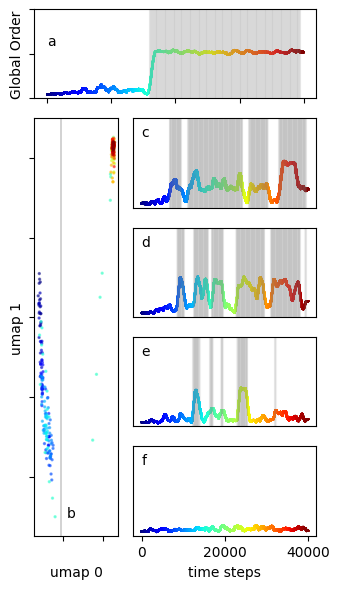

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


fig = plt.figure(figsize=([3.5, 6]))

gs = gridspec.GridSpec(10, 9)
# gs.update(wspace = 1.5, hspace = 0.3)
ax1 = plt.subplot(gs[0:2, 0:9])
# itr 136 of FN
_data = df[39].rolling(800, center=True).mean().ffill().bfill()

cmap = "jet"
with open("umap_model.pkl", "rb") as f:
    _s, _u = pickle.load(f)
chunk_size = 400
# When you increase or decrease your chunk size, you alter the persistence i.e for how long it stays in sync state
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
# create overlapping chunks with 75% overlap

# _s = StandardScaler().fit(chunks)
scaled_data = _s.transform(chunks)
# Train StandardScaler, Z score normalising values

# _u = u.fit(scaled_data)
embedding = _u.transform(scaled_data)
# Fit Umap i.e it converts 400 dimension data to 2 dimensions and we can create boundary

sep = -0.6
plt.subplots_adjust(hspace=0.8, wspace=0.8)
ax1.scatter(_data.index, _data, c=_data.index, s=0.5, cmap=cmap)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax1.axvline(l, c="gray", alpha=0.1)
ax1.set_ylabel("Global Order")
# ax1.set_xlabel('Time Steps')
# ax1.xaxis.set_visible(False)
# ax1.yaxis.set_visible(False)
ax1.set_ylim([0, 1])
ax1.text(0, 0.6, "a")

ax2 = plt.subplot(gs[2:10, 0:3])
# umap
ax2.scatter(
    embedding[:, 0], embedding[:, 1], s=2, c=range(len(chunks)), alpha=0.5, cmap=cmap
)
ax2.set_xlabel("umap 0")
ax2.set_ylabel("umap 1")
ax2.text(0.8, 1, "b")
ax2.axvline(sep, c="k", lw=0.25)
# ax2.xaxis.set_visible(False)
# ax2.yaxis.set_visible(False)
# ax1.set_ylabel('ylabel', labelpad = 0, fontsize = 12)


ax3 = plt.subplot(gs[2:4, 3:9])
# ax2.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax3.xaxis.set_visible(False)
ax3.yaxis.set_visible(False)
_data = df[136].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax3.scatter(_data.index, _data, c=_data.index, s=1, cmap=cmap)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax3.axvline(l, c="gray", alpha=0.1)
ax3.set_ylim([0, 1])
ax3.text(0, 0.8, "c")

ax4 = plt.subplot(gs[4:6, 3:9], sharex=ax3, sharey=ax3)
# ax3.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax4.xaxis.set_visible(False)
ax4.yaxis.set_visible(False)
_data = df[193].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax4.scatter(_data.index, _data, c=_data.index, s=0.5, cmap=cmap)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax4.axvline(l, c="gray", alpha=0.1)
ax4.set_ylim([0, 1])
ax4.text(0, 0.8, "d")

ax5 = plt.subplot(gs[6:8, 3:9], sharex=ax3, sharey=ax3)
# ax4.set_ylabel('ylabel', labelpad = 0, fontsize = 12)
ax5.xaxis.set_visible(False)
ax5.yaxis.set_visible(False)
_data = df[145].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax5.scatter(_data.index, _data, c=_data.index, s=0.5, cmap=cmap)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax5.axvline(l, c="gray", alpha=0.1)
ax5.set_ylim([0, 1])
ax5.text(0, 0.8, "e")

ax6 = plt.subplot(gs[8:10, 3:9], sharex=ax3, sharey=ax3)
# ax6.xaxis.set_visible(False)
ax6.yaxis.set_visible(False)
_data = df[1].rolling(800, center=True).mean().ffill().bfill()
chunks = [
    _data[i : i + chunk_size]
    for i in range(0, len(_data) - chunk_size, chunk_size // 4)
]
scaled_data = _s.transform(chunks)
embedding = _u.transform(scaled_data)
sep = -0.6
ax6.scatter(_data.index, _data, c=_data.index, s=0.5, cmap=cmap)
for l in _data.index[:-chunk_size][:: chunk_size // 4][embedding[:, 0] > sep]:
    ax6.axvline(l, c="gray", alpha=0.1)
ax6.set_ylim([0, 1])
ax6.set_xlabel("time steps")
ax6.text(0, 0.8, "f")

plt.setp(ax1.get_yticklabels(), visible=False)
plt.setp(ax1.get_xticklabels(), visible=False)


plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)

fig.align_labels()

fig.set_layout_engine(layout="tight")
# plt.savefig('fig2_final.pdf',format='pdf')
# plt.savefig('../../data/results/figures/fig2_final.svg')
# plt.savefig('../../data/results/figures/fig2_final.pdf',format='pdf')

### Figure: Structural measures effect on parameters 
- Take all nodes you have data for

#### Data folders (Containing global order, local order and node community data)
- raw/(BLA,PERI,ENTI, ORBI, RE, PIR)
- raw/check_connector
- raw/check_control

#### Data folders (containing global order and local order)
- raw/random (contains betweeness centrality data)
- raw/random_nodes
- results/processed (only global order is correct for 1000 iterations)

# Compute data for figure 3
- Read data of all the nodes from respective folders
- Find betweenness centrality, degree, nodal efficiency and eigen vector centrality for above nodes

### All the nodes for which we have to compute 

In [6]:
control_node = [251, 38, 71, 284, 1, 214, 149, 362]
control_name = ["MOB", "LSc", "MOp", "MRN"]
connector_node = [214, 1, 215, 2, 249, 36, 137, 350, 53, 266]
connector_name = ["MOp", "MOs", "PERI", "LHA", "ENTI"]
imp_nodes = [36, 249, 53, 266, 23, 236, 113, 326, 64, 277, 43, 256]
imp_name = ["PERI", "ENTI", "ORB", "RE", "BLA", "PIR"]

nodes = [
    36,
    249,
    53,
    266,
    23,
    236,
    113,
    326,
    64,
    277,
    43,
    256,
    214,
    1,
    215,
    2,
    137,
    350,
    251,
    38,
    71,
    284,
    149,
    362,
]
node_label = [
    "PERI",
    "ENTI",
    "ORB",
    "RE",
    "BLA",
    "PIR",
    "MOp",
    "MOs",
    "LHA",
    "MOB",
    "LSc",
    "MRN",
    "FN",
]

#### Calculate 
- Betweenness centrality
- Nodal Efficiency
- Degree
- Eigen vector centrality

In [7]:
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)
bet_cent = nx.betweenness_centrality(G)
deg_cent = nx.degree_centrality(G)
eig_cent = nx.eigenvector_centrality(G)
efficiency = {}
for node in G.nodes:
    # Calculate the sum of reciprocal of shortest path lengths from the node to all other nodes
    sp_lengths = nx.shortest_path_length(G, source=node)
    sum_reciprocal_sp = sum(1 / length for length in sp_lengths.values() if length > 0)

    # Calculate efficiency: E(v) = (1 / (N-1)) * sum(1 / d(v, u))
    # where N is the number of nodes and d(v, u) is the shortest path length between v and u
    efficiency[node] = sum_reciprocal_sp / (len(G.nodes) - 1)


bc_vals = []
deg_vals = []
ev_vals = []
ne_vals = []

for i in nodes:
    bc_vals.append(bet_cent[i])
    deg_vals.append(deg_cent[i])
    ev_vals.append(eig_cent[i])
    ne_vals.append(efficiency[i])

print(f"Betweenness centrality values: {bc_vals}")
print(f"Degree centrality values: {deg_vals}")
print(f"Eigen vector centrality values: {ev_vals}")
print(f"Nodal Efficiency values: {ne_vals}")

Betweenness centrality values: [0.018279655930717145, 0.018279655930717127, 0.015142250584322597, 0.015142250584322609, 0.0006490876667139932, 0.0006490876667139933, 0.01006672083950362, 0.010066720839503631, 0.0035324020639247587, 0.0035324020639247566, 0.001820790434177627, 0.0018207904341776264, 0.024213330492729394, 0.024213330492729373, 0.020510702767149596, 0.020510702767149613, 0.021876077588668236, 0.021876077588668195, 5.380812051561027e-06, 5.380812051561027e-06, 3.1673671682144285e-05, 3.1673671682144285e-05, 0.008944551377672819, 0.008944551377672819]
Degree centrality values: [0.27999999999999997, 0.27999999999999997, 0.2564705882352941, 0.2564705882352941, 0.09411764705882353, 0.09411764705882353, 0.21411764705882352, 0.21411764705882352, 0.16941176470588235, 0.16941176470588235, 0.10352941176470587, 0.10352941176470587, 0.3364705882352941, 0.3364705882352941, 0.3035294117647059, 0.3035294117647059, 0.30117647058823527, 0.30117647058823527, 0.018823529411764704, 0.0188235

In [8]:
# removing duplicate data from centrality values so that length matches
def dup_cent_rem(cent):
    j = 0
    val = []
    while j < len(cent):
        val.append(cent[j])
        j += 2

    return val


node_label_old = [
    "PERI",
    "ENTI",
    "ORB",
    "RE",
    "BLA",
    "PIR",
    "MOp",
    "MOs",
    "LHA",
    "MOB",
    "LSc",
    "MRN",
    "FN",
]
# z scoring all values
b_d = dup_cent_rem(bc_vals)
b = [(x - np.mean(b_d)) / np.std(b_d) for x in b_d]
b.append(0)

n_d = dup_cent_rem(ne_vals)
n = [(x - np.mean(n_d)) / np.std(n_d) for x in n_d]
n.append(0)

d_d = dup_cent_rem(deg_vals)
d = [(x - np.mean(d_d)) / np.std(d_d) for x in d_d]
d.append(0)

e_d = dup_cent_rem(ev_vals)
e = [(x - np.mean(e_d)) / np.std(e_d) for x in e_d]
e.append(0)

df_cent = pd.DataFrame(
    {"BET_CENT": b, "NOD_EFF": n, "DEG_CENT": d, "EIG_CENT": e}, index=node_label_old
)

df_bc = df_cent.sort_values("BET_CENT", ascending=True, inplace=False)
df_bc = df_bc.drop("FN")
print(df_bc)

      BET_CENT   NOD_EFF  DEG_CENT  EIG_CENT
MOB  -1.175187 -2.189893 -1.642223 -1.648583
LSc  -1.172221 -1.632162 -1.642223 -1.566574
ORB  -1.102570 -0.545022 -0.939980 -0.734136
PIR  -0.970389 -0.558094 -0.852200 -0.942192
BLA  -0.777301 -0.048293 -0.237738 -0.361159
MRN  -0.166753  0.574797  0.442559  0.856955
RE   -0.040160  0.356933  0.179218  0.247571
ENTI  0.532414  0.461508  0.574229  0.042929
PERI  0.886346  0.709872  0.793680  0.590284
MOs   1.138032  0.919021  1.013131  1.201774
LHA   1.292061  0.919021  0.991186  1.104563
MOp   1.555728  1.032311  1.320362  1.208568


In [9]:
df_cent.loc["FN"] = [np.NaN] * 4
df_cent.sort_values("BET_CENT", ascending=True, inplace=True)

In [10]:
df_cent

,BET_CENT,NOD_EFF,DEG_CENT,EIG_CENT
MOB,-1.175187,-2.189893,-1.642223,-1.648583
LSc,-1.172221,-1.632162,-1.642223,-1.566574
ORB,-1.102570,-0.545022,-0.939980,-0.734136
PIR,-0.970389,-0.558094,-0.852200,-0.942192
BLA,-0.777301,-0.048293,-0.237738,-0.361159
MRN,-0.166753,0.574797,0.442559,0.856955
RE,-0.040160,0.356933,0.179218,0.247571
ENTI,0.532414,0.461508,0.574229,0.042929
PERI,0.886346,0.709872,0.793680,0.590284
MOs,1.138032,0.919021,1.013131,1.201774


## Calculate 
- Number of transitions
- Transition time
- Coverage

# Calculating for all data
- Computed and stored in results

In [7]:
# read data of NOI
FN_folder = Path("../../data/raw/FN/")
ENTI_folder = Path("../../data/raw/ENTI/")
ORBI_folder = Path("../../data/raw/ORBI/")
PERI_folder = Path("../../data/raw/PERI/")
PIR_folder = Path("../../data/raw/PIR/")
RE_folder = Path("../../data/raw/RE/")
BLA_folder = Path("../../data/raw/BLA/")
files_nc = []
files_itr = []
folders = [
    FN_folder,
    PERI_folder,
    ENTI_folder,
    ORBI_folder,
    RE_folder,
    BLA_folder,
    PIR_folder,
]
for folder in folders:
    file_nc = glob.glob(str(folder / "nc_200.bz2"))
    files_nc.append(file_nc[0])
    file_itr = glob.glob(str(folder / "itr_200.bz2"))
    files_itr.append(file_itr[0])

# read data of connector nodes
data_folder = Path("../../data/raw/check_connector/")
connector_nc = glob.glob(str(data_folder / "nc_200*.bz2"))
connector_itr = glob.glob(str(data_folder / "itr_200*.bz2"))

# remove repeated nodes
connector_nc.pop(2)
connector_nc.pop(3)
connector_itr.pop(2)
connector_itr.pop(3)
connector_itr.pop(-1)

files_nc = files_nc + connector_nc
files_itr = files_itr + connector_itr

# read data of control nodes
data_folder = Path("../../data/raw/check_control/")
control_nc = glob.glob(str(data_folder / "nc_200*.bz2"))
control_itr = glob.glob(str(data_folder / "itr_200*.bz2"))

# remove repeated nodes
control_nc.pop(2)
control_itr.pop(2)
control_itr.pop(-1)

files_nc = files_nc + control_nc
files_itr = files_itr + control_itr
node_label = [
    "FN",
    "PERI",
    "ENTI",
    "ORB",
    "RE",
    "BLA",
    "PIR",
    "MOp",
    "MOs",
    "LHA",
    "MOB",
    "LSc",
    "MRN",
]

print(files_itr)
for label, f_itr in zip(node_label, files_itr):
    # df_nc = pd.read_pickle(f_nc, compression="bz2")
    df_itr = pd.read_pickle(f_itr, compression="bz2")

    # Calculating transition time and number of transitions
    params = algo_pf.compute_param_df(df_itr)

    # reader.data_dump_pkl(f'results/partial_full_data_200_itr/{label}',params)

    print(f"{f_itr} DONE")

['../../data/raw/FN/itr_200.bz2', '../../data/raw/PERI/itr_200.bz2', '../../data/raw/ENTI/itr_200.bz2', '../../data/raw/ORBI/itr_200.bz2', '../../data/raw/RE/itr_200.bz2', '../../data/raw/BLA/itr_200.bz2', '../../data/raw/PIR/itr_200.bz2', '../../data/raw/check_connector/itr_200_1.bz2', '../../data/raw/check_connector/itr_200_2.bz2', '../../data/raw/check_connector/itr_200_4.bz2', '../../data/raw/check_control/itr_200_1.bz2', '../../data/raw/check_control/itr_200_2.bz2', '../../data/raw/check_control/itr_200_4.bz2']


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

KeyboardInterrupt: 

### Save above data 

It took about 3 hour


## Read data from pkl file


In [11]:
num_trans = {}
n_p = []
n_p_s = []
n_f = []
n_f_s = []

trans_time = {}
t_p = []
t_p_s = []
t_f = []
t_f_s = []
t_p_mw = []
t_f_mw = []

fp_time = {}
f_p = []
f_p_s = []
f_f = []
f_f_s = []
f_p_mw = []
f_f_mw = []

sync_time = {}
s_p = []
s_p_s = []
s_f = []
s_f_s = []
s_p_mw = []
s_f_mw = []

cov = {}
cov_p = []
cov_p_s = []
cov_f = []
cov_f_s = []
cov_p_mw = []
cov_f_mw = []

# node_label=['PERI','ENTI','ORB','RE','BLA','PIR','MOp','MOs','LHA','MOB','LSc','MRN']
# getting nodes in ascending order
node_label = [
    "FN",
    "MOB",
    "LSc",
    "ORB",
    "PIR",
    "BLA",
    "MRN",
    "RE",
    "ENTI",
    "PERI",
    "MOs",
    "LHA",
    "MOp",
]
fn_data = reader.data_read_pkl("results/partial_full_data_200_itr/FN")

for node in node_label:
    params = reader.data_read_pkl(f"results/partial_full_data_200_itr/{node}")
    # store number of transition
    n_p.append(params[0]["n_part"])
    n_f.append(params[0]["n_full"])
    n_p_s.append(np.sqrt(params[0]["n_part"]))
    n_f_s.append(np.sqrt(params[0]["n_full"]))

    # store transition time
    t_p_s.append(np.std(params[1]["t_t"]) / np.sqrt(len(params[1]["t_t"])))
    t_f_s.append(np.std(params[2]["t_t"]) / np.sqrt(len(params[2]["t_t"])))

    t_p.append(np.mean(params[1]["t_t"]))
    _, mw = mannwhitneyu(fn_data[1]["t_t"], params[1]["t_t"])
    t_p_mw.append(mw)
    t_f.append(np.mean(params[2]["t_t"]))
    _, mw = mannwhitneyu(fn_data[2]["t_t"], params[2]["t_t"])
    t_f_mw.append(mw)

    # store first passage time
    f_p_s.append(np.std(params[1]["fp_t"]) / np.sqrt(len(params[1]["fp_t"])))
    f_f_s.append(np.std(params[2]["fp_t"]) / np.sqrt(len(params[2]["fp_t"])))

    f_p.append(np.mean(params[1]["fp_t"]))
    _, mw = mannwhitneyu(fn_data[1]["fp_t"], params[1]["fp_t"])
    f_p_mw.append(mw)
    f_f.append(np.mean(params[2]["fp_t"]))
    _, mw = mannwhitneyu(fn_data[2]["fp_t"], params[2]["fp_t"])
    f_f_mw.append(mw)

    # Store sync time
    s_p_s.append(np.std(params[1]["s_t"]) / np.sqrt(len(params[1]["s_t"])))
    s_f_s.append(np.std(params[2]["s_t"]) / np.sqrt(len(params[2]["s_t"])))

    s_p.append(np.mean(params[1]["s_t"]))
    _, mw = mannwhitneyu(fn_data[1]["s_t"], params[1]["s_t"])
    s_p_mw.append(mw)
    s_f.append(np.mean(params[2]["s_t"]))
    _, mw = mannwhitneyu(fn_data[2]["s_t"], params[2]["s_t"])
    s_f_mw.append(mw)

    # store coverage
    cov_p_s.append(np.std(params[1]["cov"]) / np.sqrt(len(params[1]["cov"])))
    cov_f_s.append(np.std(params[2]["cov"]) / np.sqrt(len(params[2]["cov"])))

    cov_p.append(np.mean(params[1]["cov"]))
    _, mw = mannwhitneyu(fn_data[1]["cov"], params[1]["cov"])
    cov_p_mw.append(mw)
    cov_f.append(np.mean(params[2]["cov"]))
    _, mw = mannwhitneyu(fn_data[2]["cov"], params[2]["cov"])
    cov_f_mw.append(mw)

num_trans = {"n_p": n_p, "n_f": n_f, "n_p_s": n_p_s, "n_f_s": n_f_s}
trans_time = {
    "t_p": t_p,
    "t_f": t_f,
    "t_p_s": t_p_s,
    "t_f_s": t_f_s,
    "t_p_mw": t_p_mw,
    "t_f_mw": t_f_mw,
}
fp_time = {
    "f_p": f_p,
    "f_f": f_f,
    "f_p_s": f_p_s,
    "f_f_s": f_f_s,
    "f_p_mw": f_p_mw,
    "f_f_mw": f_f_mw,
}

sync_time = {
    "s_p": s_p,
    "s_f": s_f,
    "s_p_s": s_p_s,
    "s_f_s": s_f_s,
    "s_p_mw": s_p_mw,
    "s_f_mw": s_f_mw,
}

cov = {
    "cov_p": cov_p,
    "cov_f": cov_f,
    "cov_p_s": cov_p_s,
    "cov_f_s": cov_f_s,
    "cov_p_mw": cov_p_mw,
    "cov_f_mw": cov_f_mw,
}

## Checking FPT and sync time data for Poisson distribution 

In [12]:
params = reader.data_read_pkl(f"results/partial_full_data_200_itr/FN")
# params[0] - number of transitions
# params[1] - Partial transitions
# params[2] - Full transitions
params[1].keys()

dict_keys(['t_t', 'fp_t', 's_t', 'cov'])

In [13]:
params[2].keys()

dict_keys(['t_t', 'fp_t', 's_t', 'cov'])

In [14]:
def exponential_fit(x, y):
    # Transform y
    log_y = np.log(y)

    # Reshape x for sklearn
    X = x.reshape(-1, 1)

    # Fit linear regression: log(y) = log(c) - m*x
    model = LinearRegression()
    model.fit(X, log_y)

    # Extract parameters
    log_c = model.intercept_
    m = -model.coef_[0]
    c = np.exp(log_c)

    # print(f"log(c) = {log_c:.4f}")
    # print(f"c = {c:.4f}")
    # print(f"m = {m:.4f}")

    # Predicted curve
    y_pred = c * np.exp(-m * x)

    # Plot
    plt.scatter(x, y, color="blue", label="Data")
    plt.plot(x, y_pred, color="red", label=f"Fit: y = {c:.2f} * exp(-{m:.4f}x)")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()
    print(f"mean: {1/m}")
    return {"c": c, "m": m, "y_pred": y_pred, "mean": 1 / m}

### Loading FPT data

In [15]:
data_folder = Path("../../data/results/partial_full_data_200_itr/")
files = []
for node in node_label:
    file = glob.glob(str(data_folder / node))
    files.append(file[0])

print(files)

['../../data/results/partial_full_data_200_itr/FN', '../../data/results/partial_full_data_200_itr/MOB', '../../data/results/partial_full_data_200_itr/LSc', '../../data/results/partial_full_data_200_itr/ORB', '../../data/results/partial_full_data_200_itr/PIR', '../../data/results/partial_full_data_200_itr/BLA', '../../data/results/partial_full_data_200_itr/MRN', '../../data/results/partial_full_data_200_itr/RE', '../../data/results/partial_full_data_200_itr/ENTI', '../../data/results/partial_full_data_200_itr/PERI', '../../data/results/partial_full_data_200_itr/MOs', '../../data/results/partial_full_data_200_itr/LHA', '../../data/results/partial_full_data_200_itr/MOp']


../../data/results/partial_full_data_200_itr/FN


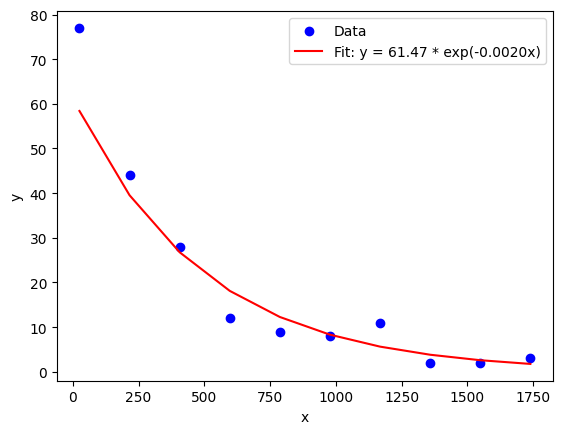

mean: 487.9448614436515
../../data/results/partial_full_data_200_itr/MOB


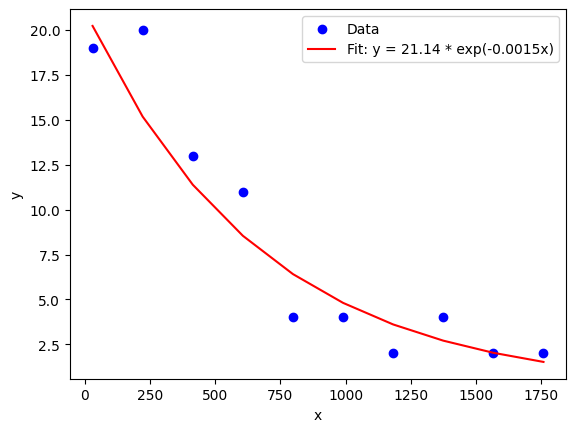

mean: 668.5343832374402
../../data/results/partial_full_data_200_itr/LSc


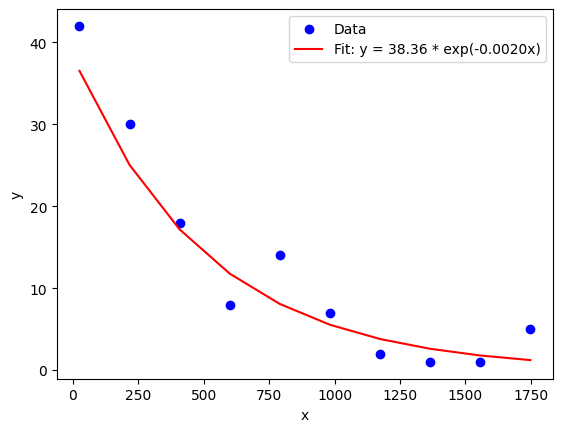

mean: 507.4570280069267
../../data/results/partial_full_data_200_itr/ORB


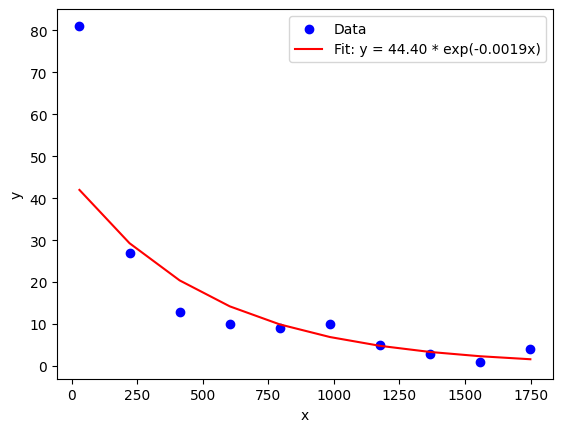

mean: 530.1091788707371
../../data/results/partial_full_data_200_itr/PIR


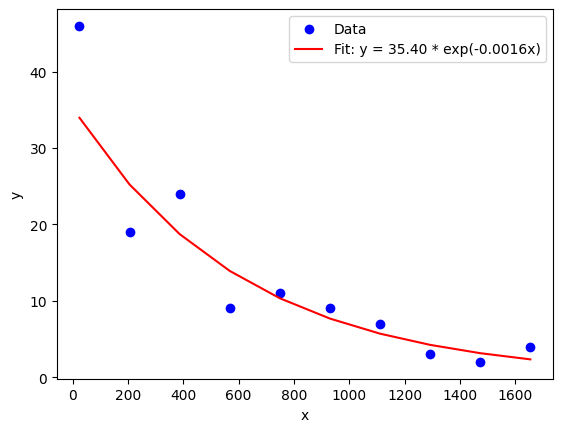

mean: 608.347745970248
../../data/results/partial_full_data_200_itr/BLA


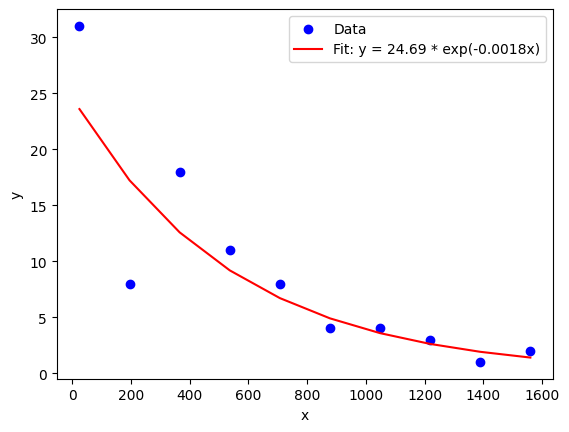

mean: 541.9434436683389
../../data/results/partial_full_data_200_itr/MRN


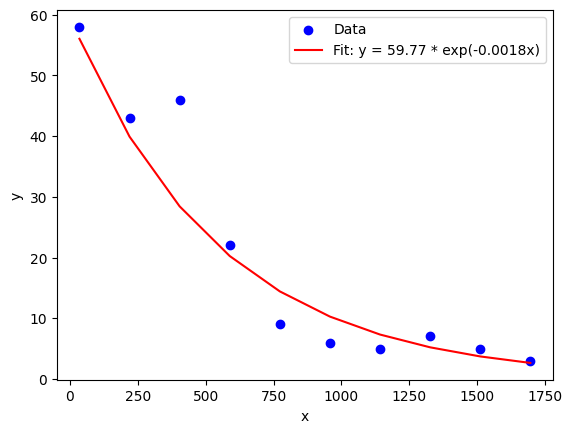

mean: 543.7836064212504
../../data/results/partial_full_data_200_itr/RE


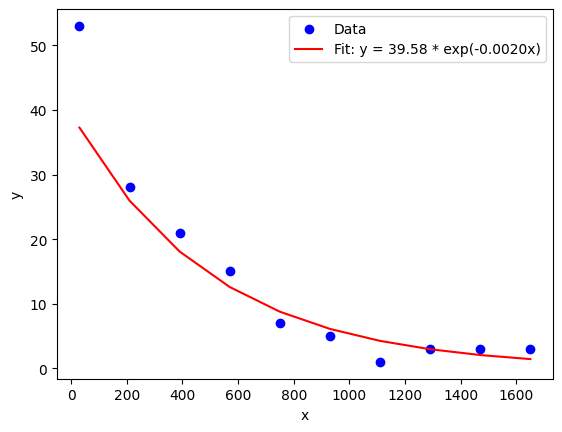

mean: 497.73392169617114
../../data/results/partial_full_data_200_itr/ENTI


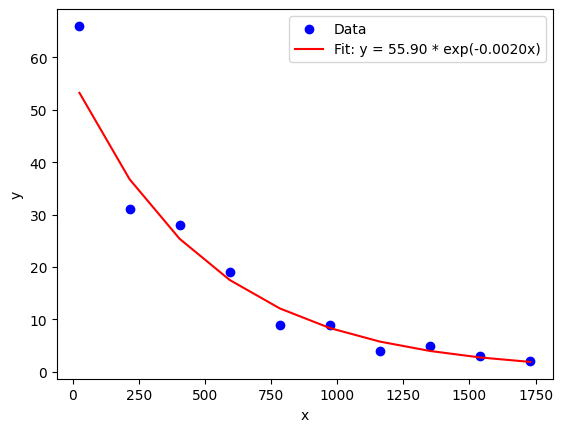

mean: 511.70569799215076
../../data/results/partial_full_data_200_itr/PERI


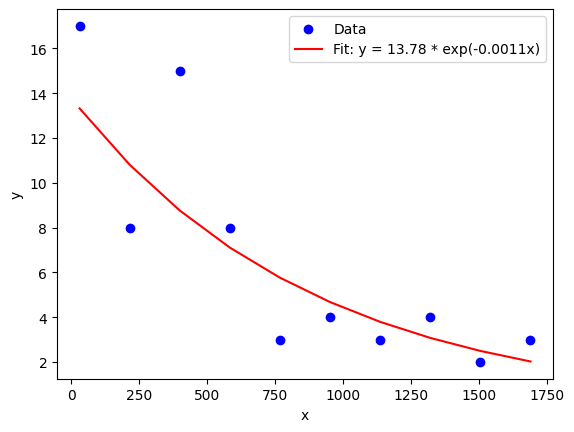

mean: 880.3739742669276
../../data/results/partial_full_data_200_itr/MOs


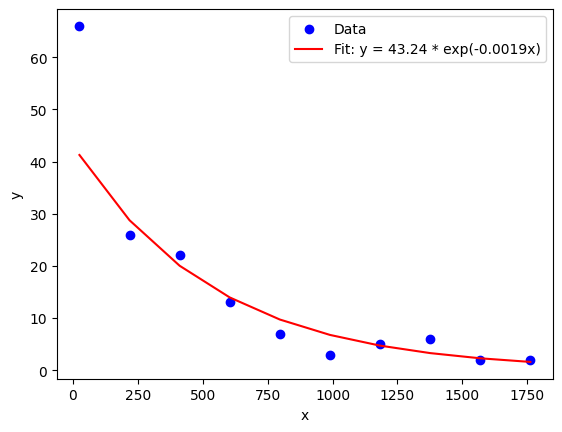

mean: 534.0122750111115
../../data/results/partial_full_data_200_itr/LHA


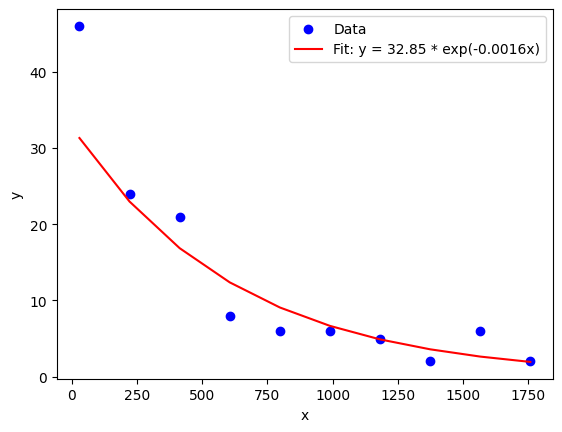

mean: 620.0774059429616
../../data/results/partial_full_data_200_itr/MOp


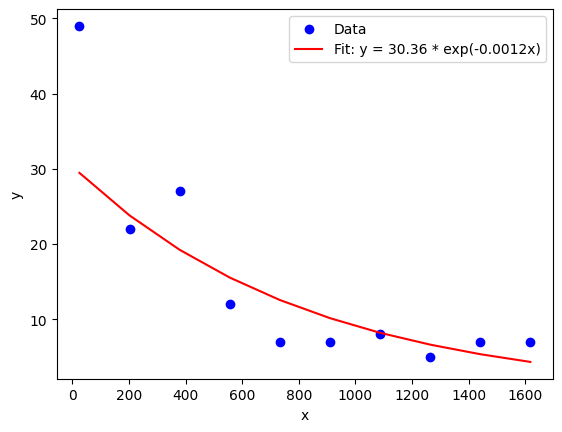

mean: 830.2180007221
fpt mean:[370.0, 790.0, 195.0, 265.0, 60.0, 130.0, 395.0, 355.0, 725.0, 140.0, 245.0, 60.0, 105.0, 25.0, 30.0, 930.0, 1400.0, 1310.0, 615.0, 470.0, 80.0, 230.0, 410.0, 425.0, 95.0, 260.0, 1040.0, 1110.0, 175.0, 470.0, 1005.0, 110.0, 125.0, 340.0, 380.0, 180.0, 1260.0, 190.0, 470.0, 1150.0, 1165.0, 415.0, 475.0, 105.0, 90.0, 185.0, 275.0, 355.0, 1675.0, 1795.0, 1130.0, 35.0, 220.0, 245.0, 770.0, 225.0, 1075.0, 435.0, 1745.0, 325.0, 420.0, 200.0, 45.0, 610.0, 45.0, 160.0, 145.0, 55.0, 460.0, 1525.0, 1545.0, 1285.0, 470.0, 1465.0, 730.0, 195.0, 820.0, 300.0, 400.0, 830.0, 75.0, 385.0, 545.0, 65.0, 195.0, 775.0, 1105.0, 740.0, 560.0, 250.0, 565.0, 495.0, 375.0, 1630.0, 470.0, 690.0, 1190.0, 310.0, 1610.0, 1745.0, 745.0, 540.0, 255.0, 65.0, 1610.0, 1630.0, 1790.0, 1380.0, 525.0, 530.0, 1530.0, 490.0, 700.0, 380.0, 1295.0, 145.0, 225.0, 680.0, 185.0, 250.0, 105.0, 75.0, 1155.0, 395.0, 445.0, 100.0, 45.0, 100.0, 40.0, 95.0, 135.0, 40.0, 25.0, 75.0, 1605.0, 1005.0, 460.0, 

In [19]:
c = []
m = []
y_pred = []
fpt = []
for item in files:
    # data = reader.data_read_pkl(item)
    print(item)
    with open(item, "rb") as f:
        data = pickle.load(f)
    fpt = data[1]["fp_t"]
    data_hist = np.histogram(fpt, bins=10)
    x = np.where(data_hist[0] == 0, 1, data_hist[0])
    y = data_hist[1]
    fit_param = exponential_fit(y[:-1], x)
    c.append(fit_param["c"])
    m.append(fit_param["m"])
    y_pred.append(fit_param["y_pred"])
    fpt.append(fit_param["mean"])
print(f"fpt mean:{fpt}")

### Sync time

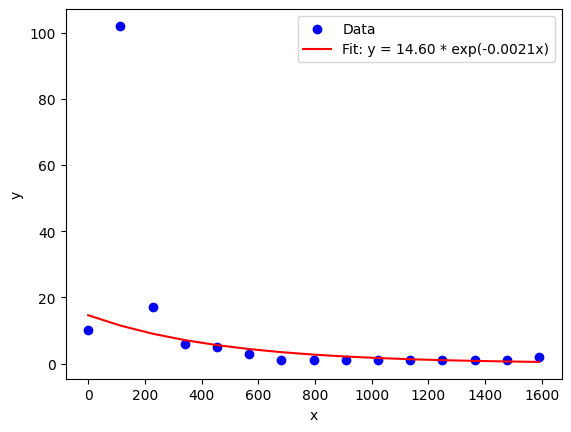

mean: 472.38414125557557


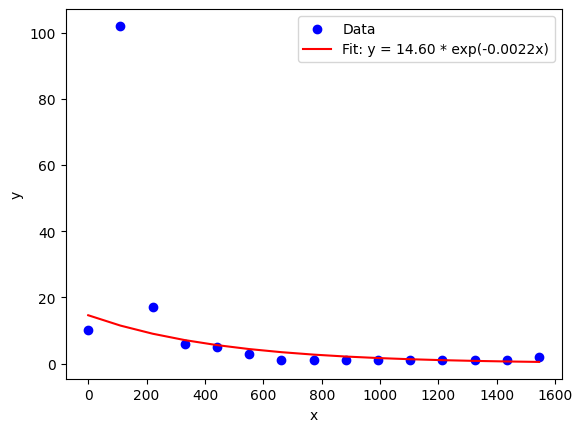

mean: 458.5312338873768


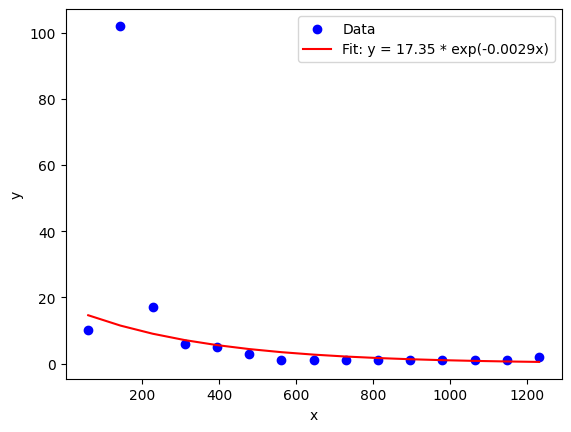

mean: 347.7079749417872


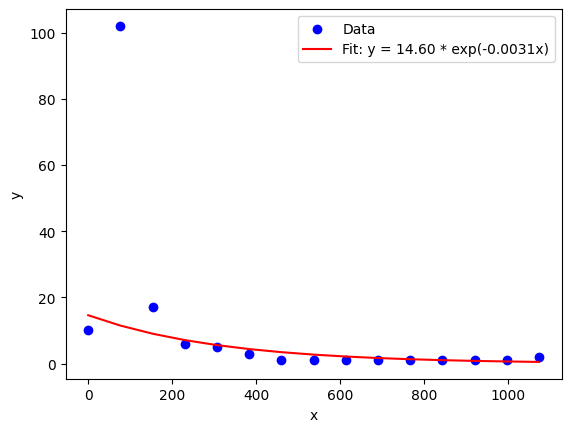

mean: 318.61686946857


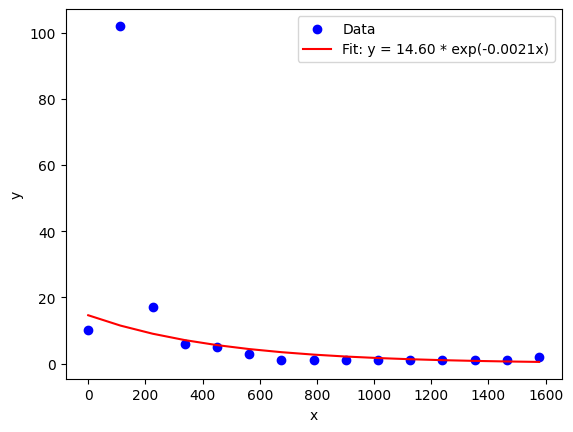

mean: 468.22826904511584


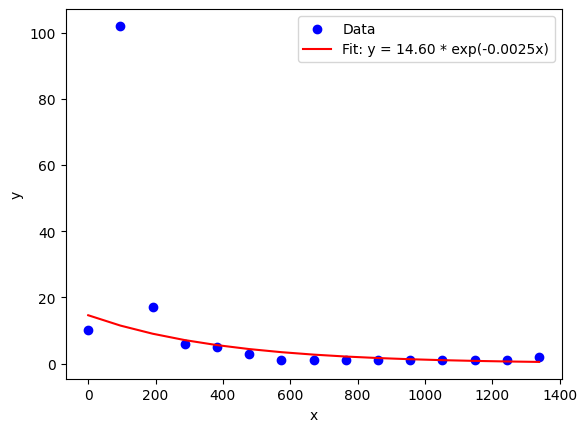

mean: 397.5784414673026


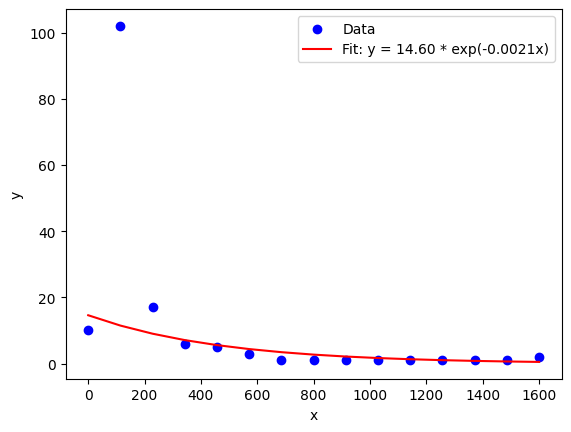

mean: 475.1547227292151


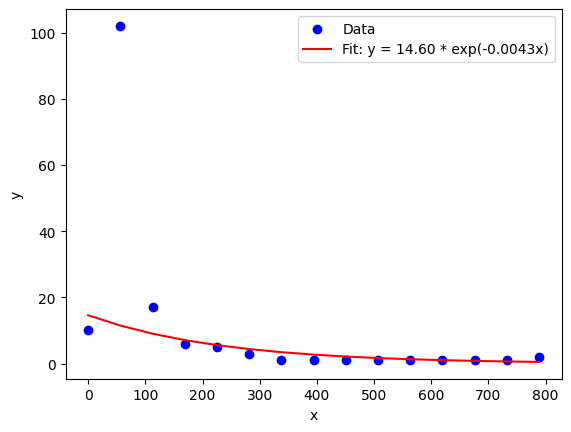

mean: 234.11413452255792


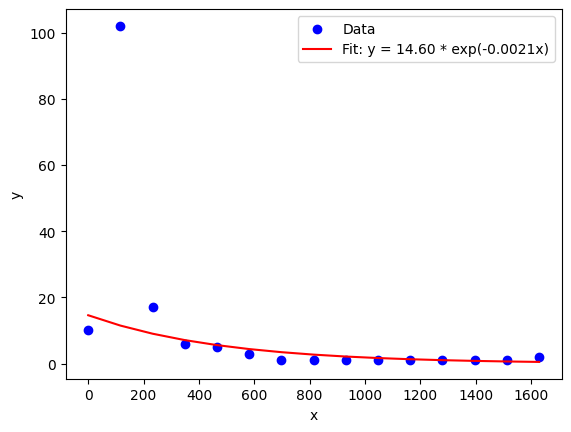

mean: 483.4664671501344


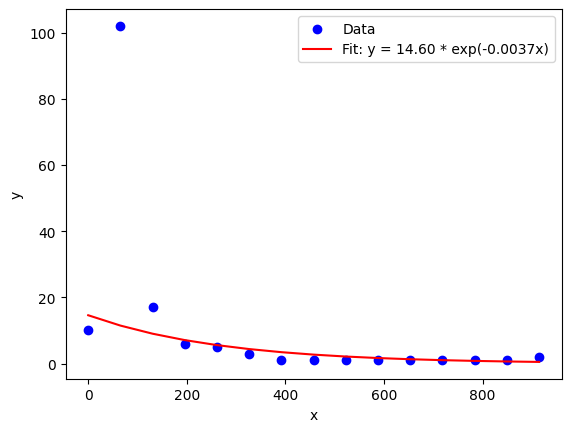

mean: 271.51698441669436


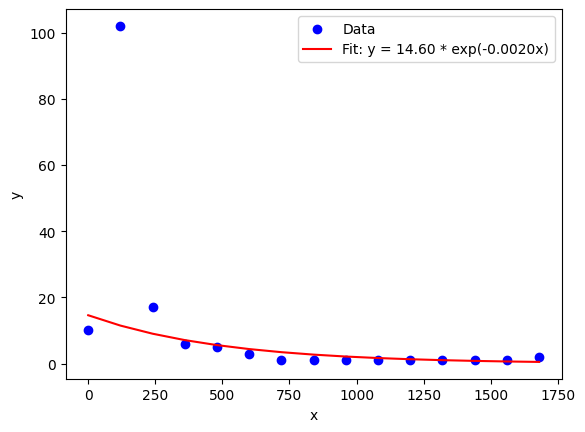

mean: 498.7046652551529


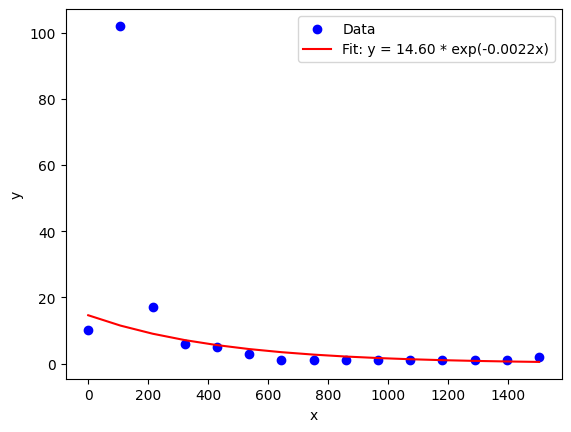

mean: 446.06361725599794


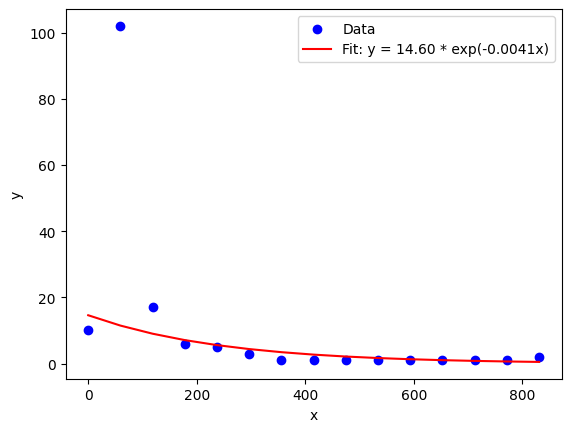

mean: 246.58175115393675
fpt mean:[0.0, 145.0, 175.0, 140.0, 80.0, 160.0, 60.0, 60.0, 115.0, 80.0, 70.0, 725.0, 230.0, 335.0, 350.0, 65.0, 65.0, 0.0, 70.0, 65.0, 70.0, 80.0, 65.0, 65.0, 890.0, 270.0, 125.0, 85.0, 90.0, 80.0, 185.0, 205.0, 380.0, 0.0, 65.0, 110.0, 85.0, 115.0, 80.0, 80.0, 60.0, 0.0, 65.0, 170.0, 65.0, 60.0, 135.0, 85.0, 60.0, 205.0, 65.0, 60.0, 225.0, 125.0, 60.0, 80.0, 80.0, 70.0, 60.0, 90.0, 70.0, 70.0, 65.0, 60.0, 60.0, 105.0, 80.0, 70.0, 120.0, 100.0, 275.0, 85.0, 0.0, 0.0, 85.0, 100.0, 70.0, 110.0, 105.0, 115.0, 145.0, 0.0, 60.0, 90.0, 60.0, 60.0, 90.0, 70.0, 75.0, 95.0, 90.0, 60.0, 60.0, 0.0, 65.0, 90.0, 65.0, 80.0, 70.0, 65.0, 90.0, 75.0, 165.0, 75.0, 85.0, 110.0, 60.0, 280.0, 95.0, 60.0, 60.0, 155.0, 65.0, 65.0, 60.0, 70.0, 345.0, 75.0, 100.0, 185.0, 0.0, 65.0, 60.0, 90.0, 125.0, 60.0, 270.0, 125.0, 125.0, 165.0, 75.0, 120.0, 75.0, 0.0, 65.0, 60.0, 90.0, 65.0, 100.0, 75.0, 60.0, 875.0, 70.0, 65.0, 60.0, 270.0, 70.0, 246.58175115393675]


In [18]:
c = []
m = []
y_pred = []
fpt = []
for item in files:
    # data = reader.data_read_pkl(item)
    # print(item)
    with open(item, "rb") as f:
        data = pickle.load(f)
    fpt = data[1]["s_t"]
    data_hist = np.histogram(fpt, bins=15)
    # x=np.where(data_hist[0]==0,1,data_hist[0])
    y = data_hist[1]
    fit_param = exponential_fit(y[:-1], x)
    c.append(fit_param["c"])
    m.append(fit_param["m"])
    y_pred.append(fit_param["y_pred"])
    fpt.append(fit_param["mean"])
print(f"fpt mean:{fpt}")

In [127]:
c = []
m = []
y_pred = []
fpt = []

[81 27 13 10  9 10  5  3  1  4]


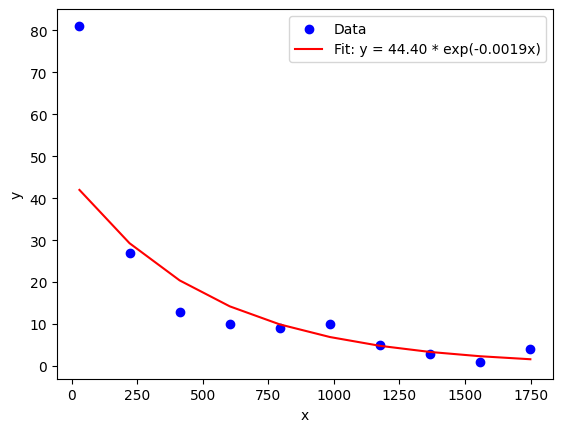

mean: 530.1091788707371


In [147]:
with open("../../data/results/partial_full_data_200_itr/ORB", "rb") as f:
    data_c = pickle.load(f)
fpt = data_c[1]["fp_t"]
data_hist = np.histogram(fpt, bins=10)
x = np.where(data_hist[0] == 0, 1, data_hist[0])
y = data_hist[1]
print(x)
fit_param = exponential_fit(y[:-1], x)
c.append(fit_param["c"])
m.append(fit_param["m"])
y_pred.append(fit_param["y_pred"])

In [129]:
fit_param

{'c': 1615.3703067182541,
 'm': 0.05227957607906856,
 'y_pred': array([  28.8408315 ,  161.90636171,  373.71421386,  862.61164888,
        1009.08909499, 1063.24719163,  908.90825963, 1454.99879191,
        1454.99879191, 1380.88623765])}

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

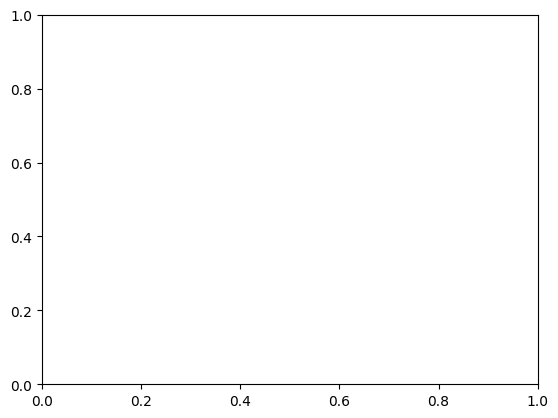

In [117]:
plt.plot(data_hist[0], y_pred)

In [111]:
1 / m[1]

15.878876511272543

In [92]:
c

[1517.3179619119392,
 1914.0010990304675,
 1768.598776257036,
 1336.1912992364155,
 1678.765292837564,
 1604.9432911566223,
 1662.3383396751447,
 1478.9446217708048,
 1648.249747240228,
 2239.195503352677,
 1513.0870627073361,
 1727.245501128621,
 2134.6812046572827]

In [100]:
m

[0.06297674771197395,
 0.13254079757278783,
 0.09322342885504831,
 0.05985918840536686,
 0.09499913220198622,
 0.11578815035762274,
 0.06600664590181492,
 0.07908546962809486,
 0.0727028794277153,
 0.16975774628512463,
 0.07109013759185086,
 0.09037547634196098,
 0.10495606587767406]

In [94]:
y_pred

[array([  23.76548237,  277.08584511,  215.38354681,  379.63531968,
         669.14570811,  976.39022046, 1179.43709522,  916.79654264,
        1179.43709522,  916.79654264, 1424.70892521, 1517.31796191,
        1256.10295398, 1337.75225267]),
 array([ 103.65349936,   90.78670027,  390.12280546,  508.53964166,
        1468.31321932, 1286.04738831, 1126.40672522, 1286.04738831,
        1468.31321932]),
 array([  38.69778167,  142.72365543,  274.09486884,  920.92523807,
         577.81960273,  696.24984712, 1467.76483545, 1467.76483545,
        1611.1756862 , 1611.1756862 , 1109.67861455]),
 array([  22.80896637,  235.48849721,  512.77211049,  779.65057321,
         878.80603962,  779.65057321,  779.65057321,  990.57203548,
        1185.42916799, 1185.42916799, 1185.42916799, 1258.55478233,
        1116.55235994]),
 array([  25.6835842 ,  367.171023  ,  228.33916313,  444.00064122,
        1148.04678398,  649.25304167,  713.95623692, 1262.45871654,
        1044.00357884, 1148.04678398, 1

## compiling in dataframe

In [43]:
a = ["num_trans"] * 2
b = ["trans_time"] * 6
c = ["fp_time"] * 6
d = ["sync_time"] * 6
e = ["cov"] * 6
upper_head = a + b + c + d + e

f = ["part", "full"]
g = ["part", "part_s", "part_mw", "full_mw", "full", "full_s"] * 4
lower_head = f + g

header = [upper_head, lower_head]
data = {
    ("num_trans", "part"): num_trans["n_p"],
    ("num_trans", "full"): num_trans["n_f"],
    ("num_trans", "part_s"): num_trans["n_p_s"],
    ("num_trans", "full_s"): num_trans["n_f_s"],
    ("trans_time", "part"): trans_time["t_p"],
    ("trans_time", "part_s"): trans_time["t_p_s"],
    ("trans_time", "part_mw"): trans_time["t_p_mw"],
    ("trans_time", "full"): trans_time["t_f"],
    ("trans_time", "full_s"): trans_time["t_f_s"],
    ("trans_time", "full_mw"): trans_time["t_p_mw"],
    ("fp_time", "part"): fp_time["f_p"],
    ("fp_time", "part_s"): fp_time["f_p_s"],
    ("fp_time", "part_mw"): fp_time["f_p_mw"],
    ("fp_time", "full"): fp_time["f_f"],
    ("fp_time", "full_s"): fp_time["f_f_s"],
    ("fp_time", "full_mw"): fp_time["f_p_mw"],
    ("sync_time", "part"): sync_time["s_p"],
    ("sync_time", "part_s"): sync_time["s_p_s"],
    ("sync_time", "part_mw"): sync_time["s_p_mw"],
    ("sync_time", "full"): sync_time["s_f"],
    ("sync_time", "full_s"): sync_time["s_f_s"],
    ("sync_time", "full_mw"): sync_time["s_p_mw"],
    ("cov", "part"): cov["cov_p"],
    ("cov", "part_s"): cov["cov_p_s"],
    ("cov", "part_mw"): cov["cov_p_mw"],
    ("cov", "full"): cov["cov_f"],
    ("cov", "full_s"): cov["cov_f_s"],
    ("cov", "full_mw"): cov["cov_p_mw"],
}

df_data = pd.DataFrame(data, index=node_label)
df_data

num_trans                            trans_time                      \
          part full     part_s     full_s       part    part_s   part_mw   
FN         196   88  14.000000   9.380832  56.995103  1.047781  1.000000   
MOB         81  115   9.000000  10.723805  49.203125  0.833819  0.000013   
LSc        128  129  11.313708  11.357817  51.542969  0.763877  0.002707   
ORB        162   95  12.727922   9.746794  54.918323  0.946086  0.350876   
PIR        134   55  11.575837   7.416198  55.444776  1.120929  0.509396   
BLA         89   56   9.433981   7.483315  58.467816  1.363351  0.134511   
MRN        204   38  14.282857   6.164414  59.736881  1.041208  0.017579   
RE         139  112  11.789826  10.583005  52.238489  1.023811  0.000850   
ENTI       176   49  13.266499   7.000000  54.834000  0.975633  0.299725   
PERI        67   56   8.185353   7.483315  55.120896  1.567229  0.388378   
MOs        152   56  12.328828   7.483315  55.483775  1.224276  0.276794   
LHA        126   49  11.224972   7.000000  53.173200  1.104826  0.027206   
MOp        151   64  12.288206   8.000000  55.335333  1.051648  0.299231   

                                     ... sync_time                         \
           full    full_s   full_mw  ...   part_mw        full     full_s   
FN    82.552273  1.715771  1.000000  ...  1.000000  133.866667  30.994419   
MOB   76.803043  1.456507  0.000013  ...  0.000015  135.809524  21.996096   
LSc   79.317829  1.302226  0.002707  ...  0.086895  133.361345  20.248536   
ORB   81.036842  1.790387  0.350876  ...  0.562591  152.816092  29.471352   
PIR   80.896364  2.101058  0.509396  ...  0.807719   88.653846  33.412629   
BLA   82.870536  2.040658  0.134511  ...  0.393939   48.207547  16.622574   
MRN   85.406579  2.170803  0.017579  ...  0.539133   13.026316  12.853774   
RE    80.105804  1.542925  0.000850  ...  0.411715  125.544554  22.377212   
ENTI  79.784694  1.901865  0.299725  ...  0.931618   86.097561  25.126398   
PERI  80.391964  2.039437  0.388378  ...  0.079963   76.792453  26.061001   
MOs   81.141964  2.043548  0.276794  ...  0.373973  171.200000  40.361506   
LHA   81.390816  1.835560  0.027206  ...  0.410971   85.326087  33.314252   
MOp   84.303906  2.031969  0.299231  ...  0.003288   55.254237  25.800993   

                     cov                                              \
       full_mw      part    part_s       part_mw      full    full_s   
FN    1.000000  0.267367  0.004511  1.000000e+00  0.478386  0.004258   
MOB   0.000015  0.228342  0.003508  6.903749e-07  0.425837  0.006644   
LSc   0.086895  0.239327  0.003257  1.211051e-04  0.446362  0.005682   
ORB   0.562591  0.256313  0.004156  7.264886e-02  0.462581  0.004901   
PIR   0.807719  0.261065  0.005264  2.532139e-01  0.481678  0.004737   
BLA   0.393939  0.275081  0.005983  2.725261e-01  0.461035  0.006035   
MRN   0.539133  0.286674  0.005140  2.909035e-02  0.501177  0.003774   
RE    0.411715  0.237213  0.003599  8.017259e-06  0.444769  0.004979   
ENTI  0.931618  0.255673  0.004555  3.480808e-02  0.456736  0.005178   
PERI  0.079963  0.263794  0.006763  7.146764e-01  0.475677  0.005545   
MOs   0.373973  0.251712  0.004272  1.177853e-02  0.453029  0.005683   
LHA   0.410971  0.250905  0.004838  1.428635e-02  0.468838  0.006253   
MOp   0.003288  0.250700  0.004595  5.417715e-03  0.466362  0.005595   

                    
           full_mw  
FN    1.000000e+00  
MOB   6.903749e-07  
LSc   1.211051e-04  
ORB   7.264886e-02  
PIR   2.532139e-01  
BLA   2.725261e-01  
MRN   2.909035e-02  
RE    8.017259e-06  
ENTI  3.480808e-02  
PERI  7.146764e-01  
MOs   1.177853e-02  
LHA   1.428635e-02  
MOp   5.417715e-03  

[13 rows x 28 columns]

In [10]:
df_data[("sync_time", "full")].loc["MRN"]

13.026315789473685

In [44]:
df = df_data.copy()

## sample bar plot check

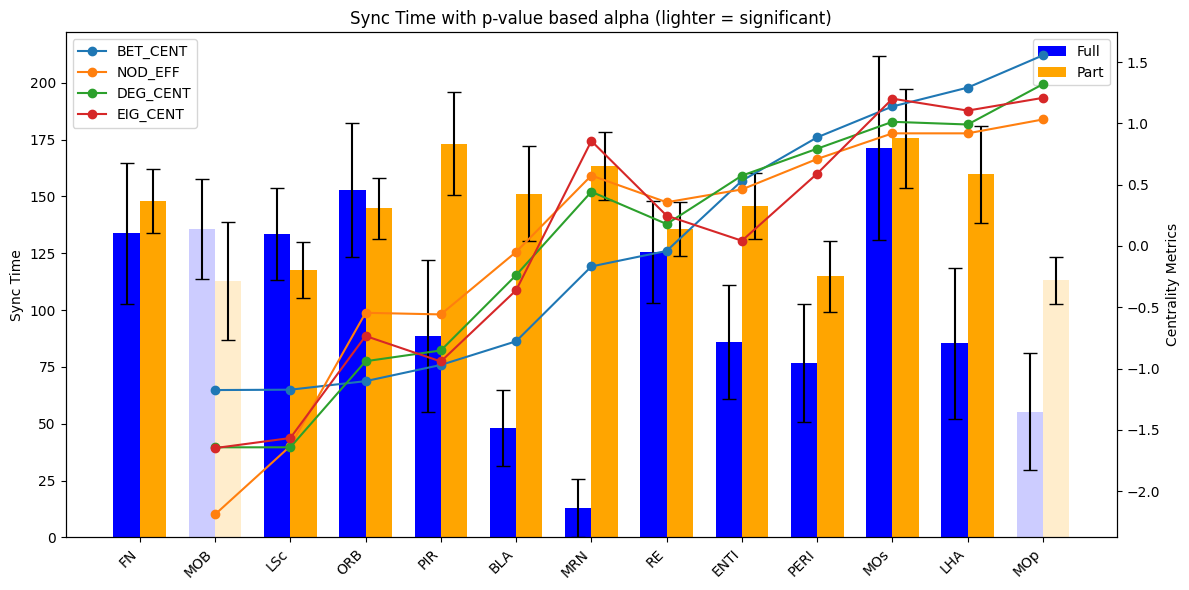

In [173]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Example: assume df is already your MultiIndex DataFrame
# Columns look like: ('sync time','full'), ('sync time','part'), ('sync time','full_s'), ('sync time','part_s')

# Extract values
full_vals = df[("sync_time", "full")]
part_vals = df[("sync_time", "part")]
full_err = df[("sync_time", "full_s")]
part_err = df[("sync_time", "part_s")]
part_mw = df[("sync_time", "part_mw")]
full_mw = df[("sync_time", "full_mw")]
# X locations
x = np.arange(len(df.index))  # one per method
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(12, 6))

# --- Plot bars individually with alpha based on p-value ---
for i, idx in enumerate(df.index):
    # alpha logic: lighter if significant
    alpha_full = 0.2 if full_mw.iloc[i] > 0.05 else 1.0
    alpha_part = 0.2 if part_mw.iloc[i] > 0.05 else 1.0

    ax.bar(
        x[i] - width / 2,
        full_vals.iloc[i],
        width,
        yerr=full_err.iloc[i],
        color="blue",
        alpha=alpha_full,
        capsize=5,
    )

    ax.bar(
        x[i] + width / 2,
        part_vals.iloc[i],
        width,
        yerr=part_err.iloc[i],
        color="orange",
        alpha=alpha_part,
        capsize=5,
    )

# Formatting
ax.set_ylabel("Sync Time")
ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=45, ha="right")
ax.legend(["Full", "Part"])

plt.title("Sync Time with p-value based alpha (darker = significant)")
plt.tight_layout()
plt.show()

## centrality separate plot

In [11]:
a = df_cent.loc[["FN"]]
df_centrality = pd.concat([a, df_bc])

In [12]:
df_centrality

,BET_CENT,NOD_EFF,DEG_CENT,EIG_CENT
FN,NaN,NaN,NaN,NaN
MOB,-1.175187,-2.189893,-1.642223,-1.648583
LSc,-1.172221,-1.632162,-1.642223,-1.566574
ORB,-1.102570,-0.545022,-0.939980,-0.734136
PIR,-0.970389,-0.558094,-0.852200,-0.942192
BLA,-0.777301,-0.048293,-0.237738,-0.361159
MRN,-0.166753,0.574797,0.442559,0.856955
RE,-0.040160,0.356933,0.179218,0.247571
ENTI,0.532414,0.461508,0.574229,0.042929
PERI,0.886346,0.709872,0.793680,0.590284


#### Shifted centrality plot

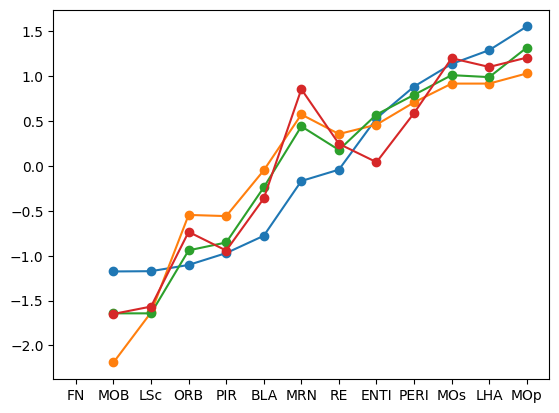

In [14]:
fig, ax2 = plt.subplots()
for col in df_centrality.columns:
    series = df_centrality[col]
    ax2.plot(series.index, series, marker="o", label=col)
    # Add red cross for NaNs
    ax2.scatter(
        series.index[series.isna()],
        [0] * series.isna().sum(),
        color="white",
        marker="x",
        zorder=5,
    )

## scatter plot between number of partial and full transitions

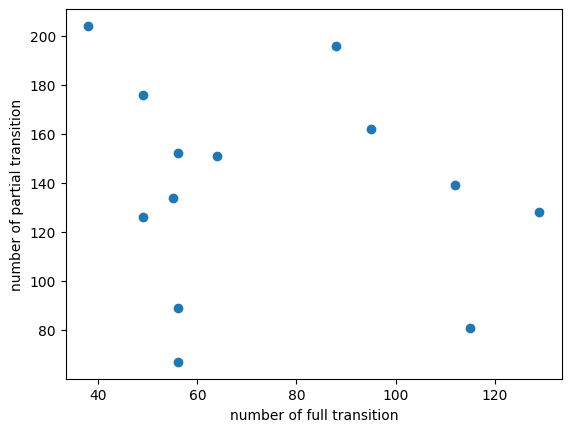

In [31]:
fig, ax = plt.subplots()
ax.scatter(df["num_trans", "full"], df[("num_trans", "part")])

ax.set_xlabel("number of full transition")
ax.set_ylabel("number of partial transition")
x = df["num_trans", "full"]
# slope, intercept, _, _, _ = linregress(df['num_trans','full'],df[('num_trans','part')])
# x_line = np.linspace(x.min(), x.max(), 100)
# y_line = slope * x_line + intercept
# ax.plot(x_line, y_line, color="orange", linestyle="--", label="Part fit")
# mannwhitneyu(df['num_trans','full'],df[('num_trans','part')])

## sample scatter plot check

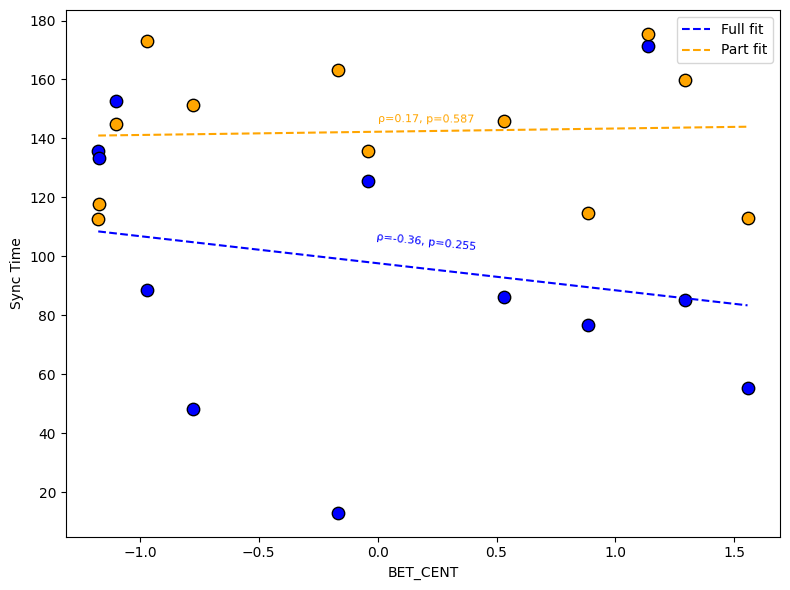

In [174]:
# Drop FN row
df_sc = df.drop("FN")
full_vals = df_sc[("sync_time", "full")]
part_vals = df_sc[("sync_time", "part")]

x = df_bc["BET_CENT"]

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# --- Scatter plots ---
ax.scatter(x, full_vals, c="blue", edgecolor="k", s=80)
ax.scatter(x, part_vals, c="orange", edgecolor="k", s=80)

# --- Full regression ---
slope, intercept, _, _, _ = linregress(x, full_vals)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="blue", linestyle="--", label="Full fit")

# Spearman correlation
rho, pval = spearmanr(x, full_vals)
mid_idx = len(x_line) // 2
x_mid, y_mid = x_line[mid_idx], y_line[mid_idx]
angle = np.degrees(np.arctan(slope)) + 78
ax.text(
    x_mid,
    y_mid + 0.05 * (full_vals.max() - full_vals.min()),
    f"ρ={rho:.2f}, p={pval:.3g}",
    fontsize=8,
    color="blue",
    ha="center",
    rotation=angle,
    rotation_mode="anchor",
)

# --- Part regression ---
slope, intercept, _, _, _ = linregress(x, part_vals)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="orange", linestyle="--", label="Part fit")

# Spearman correlation
rho, pval = spearmanr(x, part_vals)
mid_idx = len(x_line) // 2
x_mid, y_mid = x_line[mid_idx], y_line[mid_idx]
angle = np.degrees(np.arctan(slope)) - 48
ax.text(
    x_mid,
    y_mid + 0.05 * (part_vals.max() - part_vals.min()),
    f"ρ={rho:.2f}, p={pval:.3g}",
    fontsize=8,
    color="orange",
    ha="center",
    rotation=angle,
    rotation_mode="anchor",
)

# --- Labels and layout ---
ax.set_xlabel("BET_CENT")
ax.set_ylabel("Sync Time")
ax.legend()
fig.tight_layout()
plt.show()

# defining function to plot scatter plot

In [13]:
# Drop FN row
df_sc = df.drop("FN")

In [14]:
df_sc

num_trans                            trans_time                      \
          part full     part_s     full_s       part    part_s   part_mw   
MOB         81  115   9.000000  10.723805  49.203125  0.833819  0.000013   
LSc        128  129  11.313708  11.357817  51.542969  0.763877  0.002707   
ORB        162   95  12.727922   9.746794  54.918323  0.946086  0.350876   
PIR        134   55  11.575837   7.416198  55.444776  1.120929  0.509396   
BLA         89   56   9.433981   7.483315  58.467816  1.363351  0.134511   
MRN        204   38  14.282857   6.164414  59.736881  1.041208  0.017579   
RE         139  112  11.789826  10.583005  52.238489  1.023811  0.000850   
ENTI       176   49  13.266499   7.000000  54.834000  0.975633  0.299725   
PERI        67   56   8.185353   7.483315  55.120896  1.567229  0.388378   
MOs        152   56  12.328828   7.483315  55.483775  1.224276  0.276794   
LHA        126   49  11.224972   7.000000  53.173200  1.104826  0.027206   
MOp        151   64  12.288206   8.000000  55.335333  1.051648  0.299231   

                                     ... sync_time                         \
           full    full_s   full_mw  ...   part_mw        full     full_s   
MOB   76.803043  1.456507  0.000013  ...  0.000015  135.809524  21.996096   
LSc   79.317829  1.302226  0.002707  ...  0.086895  133.361345  20.248536   
ORB   81.036842  1.790387  0.350876  ...  0.562591  152.816092  29.471352   
PIR   80.896364  2.101058  0.509396  ...  0.807719   88.653846  33.412629   
BLA   82.870536  2.040658  0.134511  ...  0.393939   48.207547  16.622574   
MRN   85.406579  2.170803  0.017579  ...  0.539133   13.026316  12.853774   
RE    80.105804  1.542925  0.000850  ...  0.411715  125.544554  22.377212   
ENTI  79.784694  1.901865  0.299725  ...  0.931618   86.097561  25.126398   
PERI  80.391964  2.039437  0.388378  ...  0.079963   76.792453  26.061001   
MOs   81.141964  2.043548  0.276794  ...  0.373973  171.200000  40.361506   
LHA   81.390816  1.835560  0.027206  ...  0.410971   85.326087  33.314252   
MOp   84.303906  2.031969  0.299231  ...  0.003288   55.254237  25.800993   

                     cov                                              \
       full_mw      part    part_s       part_mw      full    full_s   
MOB   0.000015  0.228342  0.003508  6.903749e-07  0.425837  0.006644   
LSc   0.086895  0.239327  0.003257  1.211051e-04  0.446362  0.005682   
ORB   0.562591  0.256313  0.004156  7.264886e-02  0.462581  0.004901   
PIR   0.807719  0.261065  0.005264  2.532139e-01  0.481678  0.004737   
BLA   0.393939  0.275081  0.005983  2.725261e-01  0.461035  0.006035   
MRN   0.539133  0.286674  0.005140  2.909035e-02  0.501177  0.003774   
RE    0.411715  0.237213  0.003599  8.017259e-06  0.444769  0.004979   
ENTI  0.931618  0.255673  0.004555  3.480808e-02  0.456736  0.005178   
PERI  0.079963  0.263794  0.006763  7.146764e-01  0.475677  0.005545   
MOs   0.373973  0.251712  0.004272  1.177853e-02  0.453029  0.005683   
LHA   0.410971  0.250905  0.004838  1.428635e-02  0.468838  0.006253   
MOp   0.003288  0.250700  0.004595  5.417715e-03  0.466362  0.005595   

                    
           full_mw  
MOB   6.903749e-07  
LSc   1.211051e-04  
ORB   7.264886e-02  
PIR   2.532139e-01  
BLA   2.725261e-01  
MRN   2.909035e-02  
RE    8.017259e-06  
ENTI  3.480808e-02  
PERI  7.146764e-01  
MOs   1.177853e-02  
LHA   1.428635e-02  
MOp   5.417715e-03  

[12 rows x 28 columns]

In [15]:
def fig_3_scatter(ax, parameter, ang_f, ang_p):

    full_vals = df_sc[(f"{parameter}", "full")]
    part_vals = df_sc[(f"{parameter}", "part")]

    x = df_bc["BET_CENT"]

    # --- Scatter plots ---
    ax.scatter(x, full_vals, c="purple", s=3, alpha=0.4)
    ax.scatter(x, part_vals, c="orange", s=3, alpha=0.4)

    # --- Full regression ---
    slope, intercept, _, _, _ = linregress(x, full_vals)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(
        x_line, y_line, color="purple", linestyle="--", label="Full fit", linewidth=0.5
    )

    # Spearman correlation
    rho, pval = spearmanr(x, full_vals)
    mid_idx = len(x_line) // 2
    x_mid, y_mid = x_line[mid_idx], y_line[mid_idx]
    angle = np.degrees(np.arctan(slope)) + ang_f
    ax.text(
        x_mid,
        y_mid + 0.05 * (full_vals.max() - full_vals.min()),
        f"ρ={rho:.2f}, p={pval:.2g}",
        fontsize=4,
        color="purple",
        ha="center",
        rotation=angle,
        rotation_mode="anchor",
    )

    # --- Part regression ---
    slope, intercept, _, _, _ = linregress(x, part_vals)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(
        x_line, y_line, color="orange", linestyle="--", label="Part fit", linewidth=0.5
    )

    # Spearman correlation
    rho, pval = spearmanr(x, part_vals)
    mid_idx = len(x_line) // 2
    x_mid, y_mid = x_line[mid_idx], y_line[mid_idx]
    angle = np.degrees(np.arctan(slope)) + ang_p
    ax.text(
        x_mid,
        y_mid + 0.05 * (part_vals.max() - part_vals.min()),
        f"ρ={rho:.2f}, p={pval:.2g}",
        fontsize=4,
        color="orange",
        ha="center",
        rotation=angle,
        rotation_mode="anchor",
    )

    # --- Labels and layout ---
    # ax.set_xlabel("BET_CENT")
    # ax.set_ylabel(f"{parameter}")
    # ax.legend()

## defining function to plot bar plots 


In [21]:
def fig_3_bar(ax, parameter):
    # Extract values
    full_vals = df[(f"{parameter}", "full")]
    part_vals = df[(f"{parameter}", "part")]
    full_err = df[(f"{parameter}", "full_s")]
    part_err = df[(f"{parameter}", "part_s")]
    part_mw = df[(f"{parameter}", "part_mw")]
    full_mw = df[(f"{parameter}", "full_mw")]
    # X locations
    x = np.arange(len(df.index))  # one per method
    width = 0.2  # bar width

    # control_name=['MOB','LSc','MOp','MRN']
    # connector_node=[214,1,215,2,249,36,137,350,53,266]
    # connector_name=['MOp','MOs','PERI','LHA','ENTI']
    # imp_nodes=[36,249,53,266,23,236,113,326,64,277,43,256]
    # imp_name=['PERI','ENTI','ORB','RE','BLA','PIR']

    # --- Plot bars individually with alpha based on p-value ---
    for i, idx in enumerate(df.index):
        # alpha logic: darker if significant
        alpha_full = 0.4 if full_mw.iloc[i] > 0.05 else 1.0
        alpha_part = 0.4 if part_mw.iloc[i] > 0.05 else 1.0

        ax.bar(
            x[i] - width / 2,
            full_vals.iloc[i],
            width,
            yerr=full_err.iloc[i],
            color="purple",
            alpha=alpha_full,
            error_kw={
                "elinewidth": 0.3,  # thickness of error bar line
                "capsize": 0.5,  # horizontal cap length
                "capthick": 0.3,
            },
        )  # thickness of the cap lines)

        ax.bar(
            x[i] + width / 2,
            part_vals.iloc[i],
            width,
            yerr=part_err.iloc[i],
            color="orange",
            alpha=alpha_part,
            error_kw={
                "elinewidth": 0.3,  # thickness of error bar line
                "capsize": 0.5,  # horizontal cap length
                "capthick": 0.3,
            },
        )  # thickness of the cap lines)

    # Formatting
    ax.set_ylabel(f"{parameter}")
    # ax.set_xticks(x)
    # ax.set_xticklabels(df.index, rotation=45, ha="right")
    # for label in ax.get_xticklabels():
    #     text = label.get_text()
    #     if text in control_name:
    #         label.set_color('blue')
    #     elif text in connector_name:
    #         label.set_color('green')
    #     elif text in imp_name:
    #         label.set_color('red')
    #     else:
    #         label.set_color('black')

    # ax.legend(["Full", "Part"])

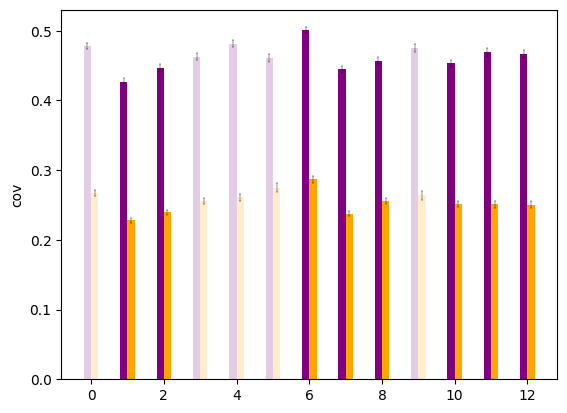

In [45]:
fig, ax02 = plt.subplots()
fig_3_bar(ax02, "cov")

## defining specifically for number of transitions


In [17]:
def fig_3_bar_num_trans(ax, parameter):
    # Extract values
    full_vals = df[(f"{parameter}", "full")]
    part_vals = df[(f"{parameter}", "part")]
    full_err = df[(f"{parameter}", "full_s")]
    part_err = df[(f"{parameter}", "part_s")]
    part_mw = 0.06
    full_mw = 0.06
    # X locations
    x = np.arange(len(df.index))  # one per method
    width = 0.2  # bar width

    # --- Plot bars individually with alpha based on p-value ---
    for i, idx in enumerate(df.index):
        # alpha logic: lighter if significant
        alpha_full = 1
        alpha_part = 1

        ax.bar(
            x[i] - width / 2,
            full_vals.iloc[i],
            width,
            yerr=full_err.iloc[i],
            color="purple",
            alpha=alpha_full,
            error_kw={
                "elinewidth": 0.3,  # thickness of error bar line
                "capsize": 0.5,  # horizontal cap length
                "capthick": 0.3,
            },
        )

        ax.bar(
            x[i] + width / 2,
            part_vals.iloc[i],
            width,
            yerr=part_err.iloc[i],
            color="orange",
            alpha=alpha_part,
            error_kw={
                "elinewidth": 0.3,  # thickness of error bar line
                "capsize": 0.5,  # horizontal cap length
                "capthick": 0.3,
            },
        )

    # Formatting
    ax.set_ylabel(f"{parameter}")
    ax.set_xticks(x)
    ax.set_xticklabels(df.index, rotation=45, ha="right")
    # ax.legend(["Full", "Part"])

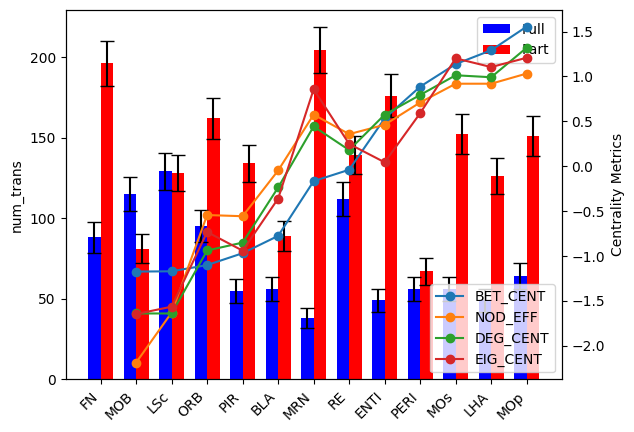

In [61]:
fig, ax02 = plt.subplots()
fig_3_bar_num_trans(ax02, "num_trans")

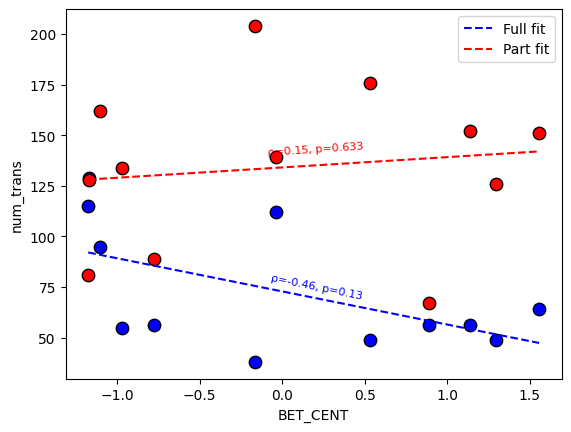

In [182]:
fig, ax01 = plt.subplots()
fig_3_scatter(ax01, "num_trans", 75, -75)

In [183]:
df.columns

MultiIndex([( 'num_trans',    'part'),
            ( 'num_trans',    'full'),
            ('trans_time',    'part'),
            ('trans_time',  'part_s'),
            ('trans_time', 'part_mw'),
            ('trans_time',    'full'),
            ('trans_time',  'full_s'),
            ('trans_time', 'full_mw'),
            (   'fp_time',    'part'),
            (   'fp_time',  'part_s'),
            (   'fp_time', 'part_mw'),
            (   'fp_time',    'full'),
            (   'fp_time',  'full_s'),
            (   'fp_time', 'full_mw'),
            ( 'sync_time',    'part'),
            ( 'sync_time',  'part_s'),
            ( 'sync_time', 'part_mw'),
            ( 'sync_time',    'full'),
            ( 'sync_time',  'full_s'),
            ( 'sync_time', 'full_mw'),
            (       'cov',    'part'),
            (       'cov',  'part_s'),
            (       'cov', 'part_mw'),
            (       'cov',    'full'),
            (       'cov',  'full_s'),
            (       'cov'

## Final Plot - Fig 3
- Arranged parameter data in order of their betweenness centrality degree
- scatter plot between betweenness centrality and each parameter

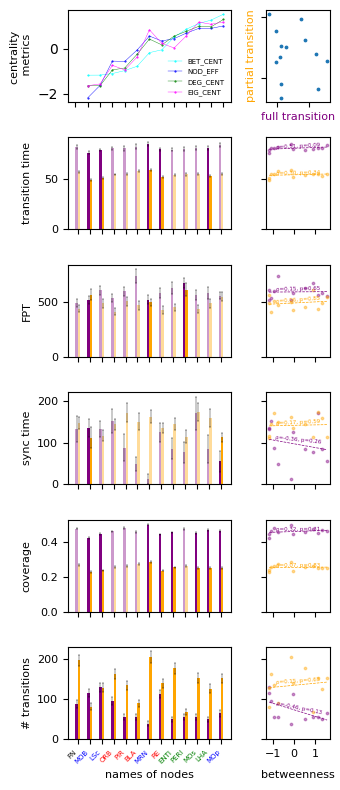

In [49]:
# fig,((ax1,ax01),(ax2,ax02),(ax3,ax03),(ax4,ax04),(ax5,ax05),(ax6,ax06))=plt.subplots(6,2,figsize=([3.5,8]),sharex='col',sharey='row')
# parameters=['trans_time','fp_time','sync_time','cov']
fig = plt.figure(figsize=([3.5, 8]))
gs = gridspec.GridSpec(12, 6)
ax1 = fig.add_subplot(gs[0:2, 0:4])
ax01 = fig.add_subplot(gs[0:2, 4:6])  # share x with ax1’s column
ax6 = fig.add_subplot(gs[10:12, 0:4])
ax2 = fig.add_subplot(gs[2:4, 0:4], sharex=ax6)
ax02 = fig.add_subplot(gs[2:4, 4:6], sharey=ax2)
ax3 = fig.add_subplot(gs[4:6, 0:4], sharex=ax6)
ax03 = fig.add_subplot(gs[4:6, 4:6], sharey=ax3)
ax4 = fig.add_subplot(gs[6:8, 0:4], sharex=ax6)
ax04 = fig.add_subplot(gs[6:8, 4:6], sharey=ax4)
ax5 = fig.add_subplot(gs[8:10, 0:4], sharex=ax6)
ax05 = fig.add_subplot(gs[8:10, 4:6], sharey=ax5)

ax06 = fig.add_subplot(gs[10:12, 4:6], sharey=ax6)


plt.subplots_adjust(hspace=0.5, wspace=0.5)  # increase vertical space between rows

# Plot each centrality metric starting from MOB
# Define your custom color set (one per column)
colors = ["cyan", "blue", "green", "magenta"]
# You can use hex codes, named colors, or RGB tuples

for col, color in zip(df_centrality.columns, colors):
    series = df_centrality[col]
    ax1.plot(
        series.index,
        series,
        marker="o",
        markersize=0.5,
        linewidth=0.3,
        label=col,
        color=color,
    )
    # Add cross for NaNs (use same color or fixed red/white)
    ax1.scatter(
        series.index[series.isna()],
        [0] * series.isna().sum(),
        color="white",
        marker="x",
        zorder=5,
    )


ax1.set_ylabel("centrality \n metrics", fontsize=8)
ax1.legend(loc="lower right", fontsize=5, frameon=False)


ax01.scatter(df["num_trans", "full"], df[("num_trans", "part")], s=3)
ax01.set_xlabel("full transition", fontsize=8, color="purple")
ax01.set_ylabel("partial transition", fontsize=8, color="orange")


# x=df[('num_trans','full')]
# part_vals=df[('num_trans','part')]
# slope, intercept, _, _, _ = linregress(x, part_vals)
# x_line = np.linspace(x.min(), x.max(), 100)
# y_line = slope * x_line + intercept
# ax01.plot(x_line, y_line, color="blue", linestyle="--", label="Part fit",linewidth=0.5)

# # Spearman correlation
# rho, pval = spearmanr(x, part_vals)
# mid_idx = len(x_line) // 2
# x_mid, y_mid = x_line[mid_idx], y_line[mid_idx]
# angle = np.degrees(np.arctan(slope)) + 10
# ax01.text(x_mid, y_mid + 0.05*(part_vals.max()-part_vals.min()),
#         f"ρ={rho:.2f}, p={pval:.2g}",
#         fontsize=4, color="blue", ha="center",
#         rotation=angle, rotation_mode="anchor")


# ax01.set_ylabel('number of partial transition')
x = df["num_trans", "full"]


fig_3_bar_num_trans(ax6, "num_trans")
ax6.set_ylabel("# transitions", fontsize=8)
# ax1.legend(["Full", "Part"])
fig_3_scatter(ax06, "num_trans", 75, -75)
# ax01.legend()


fig_3_bar(ax2, "trans_time")
ax2.set_ylabel("transition time", fontsize=8)
fig_3_scatter(ax02, "trans_time", -35, -25)


fig_3_bar(ax3, "fp_time")
ax3.set_ylabel("FPT", fontsize=8)
# ax3.set_ylabel('first passage time',fontsize=8)
fig_3_scatter(ax03, "fp_time", -55, -80)


fig_3_bar(ax4, "sync_time")
ax4.set_ylabel("sync time", fontsize=8)
fig_3_scatter(ax04, "sync_time", 78, -45)


fig_3_bar(ax5, "cov")
ax5.set_ylabel("coverage", fontsize=8)
ax6.set_xlabel("names of nodes", fontsize=8)
fig_3_scatter(ax05, "cov", 0, 0)
ax06.set_xlabel("betweenness", fontsize=8)


control_name = ["MOB", "LSc", "MOp", "MRN"]
connector_node = [214, 1, 215, 2, 249, 36, 137, 350, 53, 266]
connector_name = ["MOp", "MOs", "PERI", "LHA", "ENTI"]
imp_nodes = [36, 249, 53, 266, 23, 236, 113, 326, 64, 277, 43, 256]
imp_name = ["PERI", "ENTI", "ORB", "RE", "BLA", "PIR"]

#
# plt.setp(ax1.get_yticklabels(), fontsize=8)
plt.setp(ax2.get_yticklabels(), fontsize=8)
plt.setp(ax3.get_yticklabels(), fontsize=8)
plt.setp(ax4.get_yticklabels(), fontsize=8)
plt.setp(ax5.get_yticklabels(), fontsize=8)
plt.setp(ax6.get_yticklabels(), fontsize=8)

plt.setp(ax01.get_yticklabels(), visible=False)
plt.setp(ax02.get_yticklabels(), visible=False)
plt.setp(ax03.get_yticklabels(), visible=False)
plt.setp(ax04.get_yticklabels(), visible=False)
plt.setp(ax05.get_yticklabels(), visible=False)
plt.setp(ax06.get_yticklabels(), visible=False)


plt.setp(ax01.get_xticklabels(), visible=False)
plt.setp(ax02.get_xticklabels(), visible=False)
plt.setp(ax03.get_xticklabels(), visible=False)
plt.setp(ax04.get_xticklabels(), visible=False)
plt.setp(ax05.get_xticklabels(), visible=False)

plt.setp(ax06.get_xticklabels(), fontsize=8)

# plt.setp(ax01.get_xticklabels(), visible=False)
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax4.get_xticklabels(), visible=False)
plt.setp(ax5.get_xticklabels(), visible=False)

x = np.arange(len(df.index))
ax6.set_xticks(x)
ax6.set_xticklabels(df.index, rotation=45, ha="right", fontsize=5)
for label in ax6.get_xticklabels():
    text = label.get_text()
    if text in control_name:
        label.set_color("blue")
    elif text in connector_name:
        label.set_color("green")
    elif text in imp_name:
        label.set_color("red")
    else:
        label.set_color("black")
# f.suptitle('Figure 3')
# f.tight_layout()

fig.align_labels()

fig.set_layout_engine(layout="tight")


# plt.savefig('../../data/results/figures/fig3_final.pdf',format='pdf')

# plt.savefig('../../data/results/figures/fig3_final.svg')

In [31]:
df_bc.index

Index(['MOB', 'LSc', 'ORB', 'PIR', 'BLA', 'MRN', 'RE', 'ENTI', 'PERI', 'MOs',
       'LHA', 'MOp'],
      dtype='object')

# Functional Metrics - Figure 4

- Plot on median time spent vs degree plot
- Dark grey for data nodes
- Light grey for non data nodes

#### Getting  median time spent and degree values for all nodes

In [24]:
df_nc = reader.data_read_bz2("raw/FN/nc_200.bz2")
df_itr = reader.data_read_bz2("raw/FN/itr_200.bz2")
# here G is the undirected graph
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)
df_r = df_nc.reset_index(drop=True)


i = 0
f = 5000
time_list = []
node_list = []
while f < df_r.shape[0]:
    l = analyse.compute_time_spent_mc(df_r.iloc[i:f, :])
    node_list.append(l)
    i = f
    f += 5000

df_time_spent = pd.DataFrame(node_list)
df_time_spent.shape

# calculate median of every column
MTS = df_time_spent.median()
med_time_spent = list(MTS)
keys = list(range(0, 426))
mts_dict = dict(zip(keys, med_time_spent))
mts_sorted = dict(sorted(mts_dict.items(), key=lambda item: item[1]))

degree = nx.degree_centrality(G)
degree_val = list(degree.values())

#### Getting MTS values for our nodes

In [25]:
mts_vals = []
nodes_half = [36, 53, 23, 113, 64, 43, 1, 215, 137, 38, 71, 149]
# storing mts values
for i in nodes_half:
    mts_vals.append(mts_dict[i])
print(mts_vals)

# storing degree values
deg_vals = [degree_val[i] for i in nodes_half]
#  nodes of interest
noi = [36, 53, 23, 113, 64, 43]
noi_vals = [mts_dict[i] for i in noi]
noi_deg = [degree_val[i] for i in noi]
# connector
coi = [1, 215, 36, 137, 53]
coi_vals = [mts_dict[i] for i in coi]
coi_deg = [degree_val[i] for i in coi]
# control
cni = [38, 71, 1, 149]
cni_vals = [mts_dict[i] for i in cni]
cni_deg = [degree_val[i] for i in cni]

cn = ["ENTI", "PERI"]
cn_num = [36, 53]
cn_vals = [mts_dict[i] for i in cn_num]
cn_deg = [degree_val[i] for i in cn_num]

[1657.0, 1582.0, 1696.0, 1577.0, 1711.0, 1716.0, 436.0, 1368.0, 961.0, 1880.0, 1560.0, 257.0]


In [206]:
full_vals

FN      133.866667
MOB     135.809524
LSc     133.361345
ORB     152.816092
PIR      88.653846
BLA      48.207547
MRN      13.026316
RE      125.544554
ENTI     86.097561
PERI     76.792453
MOs     171.200000
LHA      85.326087
MOp      55.254237
Name: (sync_time, full), dtype: float64

In [26]:
## defining function for scatter plots param wrt mts


def fig_4_scatter_mts(ax, parameter, ang_f, ang_p):

    x = mts_vals
    full_vals = df_sc[(f"{parameter}", "full")]
    part_vals = df_sc[(f"{parameter}", "part")]
    ax.scatter(mts_vals, full_vals, color="purple", s=3, alpha=0.5)
    ax.scatter(mts_vals, part_vals, color="orange", s=3, alpha=0.5)

    # --- Full regression ---
    x = np.asarray(x)
    slope, intercept, _, _, _ = linregress(x, full_vals)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(
        x_line, y_line, color="purple", linestyle="--", label="Full fit", linewidth=0.5
    )

    # Spearman correlation
    rho, pval = spearmanr(x, full_vals)
    mid_idx = len(x_line) // 2
    x_mid, y_mid = x_line[mid_idx], y_line[mid_idx]
    angle = np.degrees(np.arctan(slope)) + ang_f
    ax.text(
        x_mid,
        y_mid + 0.05 * (full_vals.max() - full_vals.min()),
        f"ρ={rho:.2f}, p={pval:.2g}",
        fontsize=4,
        color="purple",
        ha="center",
        rotation=angle,
        rotation_mode="anchor",
    )

    # --- Part regression ---
    slope, intercept, _, _, _ = linregress(x, part_vals)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(
        x_line, y_line, color="orange", linestyle="--", label="Part fit", linewidth=0.5
    )

    # Spearman correlation
    rho, pval = spearmanr(x, part_vals)
    mid_idx = len(x_line) // 2
    x_mid, y_mid = x_line[mid_idx], y_line[mid_idx]
    angle = np.degrees(np.arctan(slope)) + ang_p
    ax.text(
        x_mid,
        y_mid + 0.05 * (part_vals.max() - part_vals.min()),
        f"ρ={rho:.2f}, p={pval:.2g}",
        fontsize=4,
        color="orange",
        ha="center",
        rotation=angle,
        rotation_mode="anchor",
    )

In [27]:
## defining function for scatter plots param wrt degree


def fig_4_scatter_deg(ax, parameter, ang_f, ang_p):

    x = deg_vals
    full_vals = df_sc[(f"{parameter}", "full")]
    part_vals = df_sc[(f"{parameter}", "part")]
    ax.scatter(x, full_vals, color="purple", s=3, alpha=0.5)
    ax.scatter(x, part_vals, color="orange", s=3, alpha=0.5)

    # --- Full regression ---
    x = np.asarray(x)
    slope, intercept, _, _, _ = linregress(x, full_vals)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(
        x_line, y_line, color="purple", linestyle="--", label="Full fit", linewidth=0.5
    )

    # Spearman correlation
    rho, pval = spearmanr(x, full_vals)
    mid_idx = len(x_line) // 2
    x_mid, y_mid = x_line[mid_idx], y_line[mid_idx]
    angle = np.degrees(np.arctan(slope)) + ang_f
    ax.text(
        x_mid,
        y_mid + 0.05 * (full_vals.max() - full_vals.min()),
        f"ρ={rho:.2f}, p={pval:.2g}",
        fontsize=4,
        color="purple",
        ha="center",
        rotation=angle,
        rotation_mode="anchor",
    )

    # --- Part regression ---
    slope, intercept, _, _, _ = linregress(x, part_vals)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(
        x_line, y_line, color="orange", linestyle="--", label="Part fit", linewidth=0.5
    )

    # Spearman correlation
    rho, pval = spearmanr(x, part_vals)
    mid_idx = len(x_line) // 2
    x_mid, y_mid = x_line[mid_idx], y_line[mid_idx]
    angle = np.degrees(np.arctan(slope)) + ang_p
    ax.text(
        x_mid,
        y_mid + 0.05 * (part_vals.max() - part_vals.min()),
        f"ρ={rho:.2f}, p={pval:.2g}",
        fontsize=4,
        color="orange",
        ha="center",
        rotation=angle,
        rotation_mode="anchor",
    )

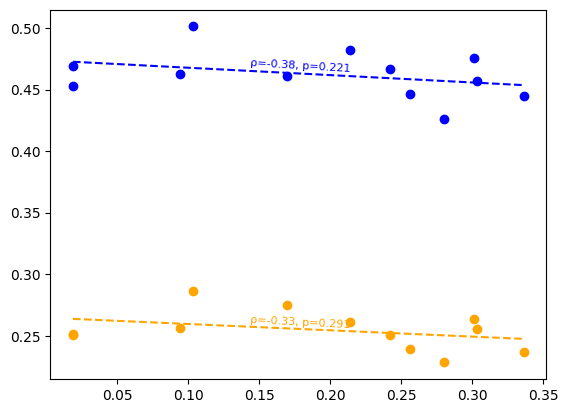

In [121]:
fig, ax = plt.subplots()
# fig_4_scatter_deg(ax,'trans_time',80,80)
# fig_4_scatter_deg(ax,'num_trans',-80,80)
# fig_4_scatter_deg(ax,'sync_time',85,75)
# fig_4_scatter_deg(ax,'fp_time',-85,-80)
# fig_4_scatter_deg(ax,'cov',0,0)

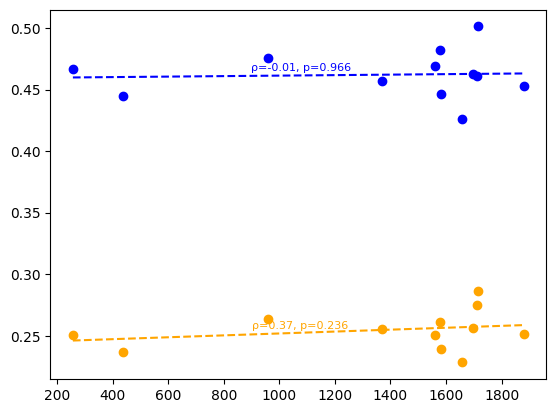

In [92]:
fig, ax = plt.subplots()
# fig_4_scatter_mts(ax,'trans_time',0,0)
# fig_4_scatter_mts(ax,'num_trans',0,0)
# fig_4_scatter_mts(ax,'sync_time',5,8)
# fig_4_scatter_mts(ax,'fp_time',0,-5)
# fig_4_scatter_mts(ax,'cov',0,0)

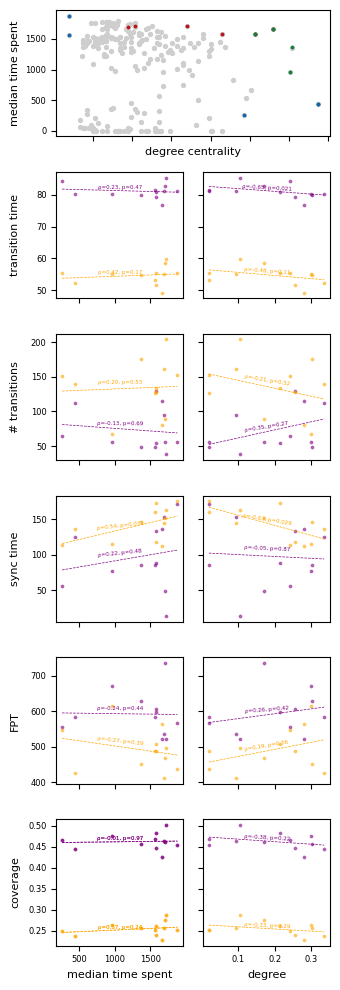

In [30]:
fig = plt.figure(figsize=(3.5, 10))
gs = gridspec.GridSpec(12, 4)

plt.subplots_adjust(hspace=0.8, wspace=0.8)
cn = ["ENTI", "PERI"]
ax1 = plt.subplot(gs[0:2, 0:4])
ax1.scatter(degree_val[0:213], med_time_spent[0:213], s=8, color=cm.Greys(0.3))
ax1.scatter(cn_deg, cn_vals, s=3, color=cm.Reds(0.8), edgecolors=cm.Greens(0.8))
ax1.scatter(noi_deg, noi_vals, s=3, color=cm.Reds(0.8), label="NOI")
ax1.scatter(coi_deg, coi_vals, s=3, color=cm.Greens(0.8), label="Connector")
ax1.scatter(cni_deg, cni_vals, s=3, color=cm.Blues(0.8), label="Control")
ax1.tick_params(axis="both", labelsize=6)

ax1.set_xlabel("degree centrality", fontsize=8)
ax1.set_ylabel("median time spent", fontsize=8)

ax6 = plt.subplot(gs[10:12, 0:2])
fig_4_scatter_mts(ax6, "cov", 0, 0)
ax6.tick_params(axis="both", labelsize=6)

ax2 = plt.subplot(gs[2:4, 0:2], sharex=ax6)
ax2.tick_params(axis="both", labelsize=6)
fig_4_scatter_mts(ax2, "trans_time", 0, 0)
ax2.set_ylabel("transition time", fontsize=8)
ax02 = plt.subplot(gs[2:4, 2:4], sharey=ax2)
fig_4_scatter_deg(ax02, "trans_time", 80, 80)

ax3 = plt.subplot(gs[4:6, 0:2], sharex=ax6)
ax3.tick_params(axis="both", labelsize=6)
fig_4_scatter_mts(ax3, "num_trans", 0, 0)
ax3.set_ylabel("# transitions", fontsize=8)
ax03 = plt.subplot(gs[4:6, 2:4], sharey=ax3)
fig_4_scatter_deg(ax03, "num_trans", -80, 80)

ax4 = plt.subplot(gs[6:8, 0:2], sharex=ax6)
ax4.tick_params(axis="both", labelsize=6)
fig_4_scatter_mts(ax4, "sync_time", 5, 5)
ax4.set_ylabel("sync time", fontsize=8)
ax04 = plt.subplot(gs[6:8, 2:4], sharey=ax4)
fig_4_scatter_deg(ax04, "sync_time", 85, 80)

ax5 = plt.subplot(gs[8:10, 0:2], sharex=ax6)
ax5.tick_params(axis="both", labelsize=6)
fig_4_scatter_mts(ax5, "fp_time", 0, -5)
ax5.set_ylabel("FPT", fontsize=8)
ax05 = plt.subplot(gs[8:10, 2:4], sharey=ax5)
fig_4_scatter_deg(ax05, "fp_time", -85, -80)


fig_4_scatter_mts(ax6, "cov", 0, 0)
ax6.set_ylabel("coverage", fontsize=8)
ax6.set_xlabel("median time spent", fontsize=8)
ax06 = plt.subplot(gs[10:12, 2:4], sharey=ax6)
fig_4_scatter_deg(ax06, "cov", 0, 0)
ax06.tick_params(axis="both", labelsize=6)
ax06.set_xlabel("degree", fontsize=8)


plt.setp(ax01.get_yticklabels(), visible=False)
plt.setp(ax02.get_yticklabels(), visible=False)
plt.setp(ax03.get_yticklabels(), visible=False)
plt.setp(ax04.get_yticklabels(), visible=False)
plt.setp(ax05.get_yticklabels(), visible=False)
plt.setp(ax06.get_yticklabels(), visible=False)


plt.setp(ax01.get_xticklabels(), visible=False)
plt.setp(ax02.get_xticklabels(), visible=False)
plt.setp(ax03.get_xticklabels(), visible=False)
plt.setp(ax04.get_xticklabels(), visible=False)
plt.setp(ax05.get_xticklabels(), visible=False)
# plt.setp(ax06.get_xticklabels(), visible=False)

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax4.get_xticklabels(), visible=False)
plt.setp(ax5.get_xticklabels(), visible=False)
# plt.setp(ax6.get_xticklabels(), visible=False)
# plt.setp(ax5.get_xticklabels(), visible=False)
# plt.tight_layout()
# plt.savefig('fig_4.png')
fig.set_layout_engine(layout="tight")
fig.align_labels()
# plt.savefig('../../data/results/figures/fig4_final.pdf',format='pdf')

plt.savefig("../../data/results/figures/fig4_final.svg")

## Plot for 1000 iterations

In [185]:
num_trans = {}
n_p = []
n_p_s = []
n_f = []
n_f_s = []

trans_time = {}
t_p = []
t_p_s = []
t_f = []
t_f_s = []
t_p_mw = []
t_f_mw = []

fp_time = {}
f_p = []
f_p_s = []
f_f = []
f_f_s = []
f_p_mw = []
f_f_mw = []

sync_time = {}
s_p = []
s_p_s = []
s_f = []
s_f_s = []
s_p_mw = []
s_f_mw = []

cov = {}
cov_p = []
cov_p_s = []
cov_f = []
cov_f_s = []
cov_p_mw = []
cov_f_mw = []

# node_label=['PERI','ENTI','ORB','RE','BLA','PIR','MOp','MOs','LHA','MOB','LSc','MRN']
# getting nodes in ascending order
node_label = ["fn", "orbi", "pir", "bla", "re", "enti", "peri"]
fn_data = reader.data_read_pkl("results/partial_full_data_1000_itr/fn")

for node in node_label:
    params = reader.data_read_pkl(f"results/partial_full_data_1000_itr/{node}")
    # store number of transition
    n_p.append(params[0]["n_part"])
    n_f.append(params[0]["n_full"])

    # store transition time
    t_p_s.append(np.std(params[1]["t_t"]) / np.sqrt(len(params[1]["t_t"])))
    t_f_s.append(np.std(params[2]["t_t"]) / np.sqrt(len(params[2]["t_t"])))

    t_p.append(np.mean(params[1]["t_t"]))
    _, mw = mannwhitneyu(fn_data[1]["t_t"], params[1]["t_t"])
    t_p_mw.append(mw)
    t_f.append(np.mean(params[2]["t_t"]))
    _, mw = mannwhitneyu(fn_data[2]["t_t"], params[2]["t_t"])
    t_f_mw.append(mw)

    # store first passage time
    f_p_s.append(np.std(params[1]["fp_t"]) / np.sqrt(len(params[1]["fp_t"])))
    f_f_s.append(np.std(params[2]["fp_t"]) / np.sqrt(len(params[2]["fp_t"])))

    f_p.append(np.mean(params[1]["fp_t"]))
    _, mw = mannwhitneyu(fn_data[1]["fp_t"], params[1]["fp_t"])
    f_p_mw.append(mw)
    f_f.append(np.mean(params[2]["fp_t"]))
    _, mw = mannwhitneyu(fn_data[2]["fp_t"], params[2]["fp_t"])
    f_f_mw.append(mw)

    # Store sync time
    s_p_s.append(np.std(params[1]["s_t"]) / np.sqrt(len(params[1]["s_t"])))
    s_f_s.append(np.std(params[2]["s_t"]) / np.sqrt(len(params[2]["s_t"])))

    s_p.append(np.mean(params[1]["s_t"]))
    _, mw = mannwhitneyu(fn_data[1]["s_t"], params[1]["s_t"])
    s_p_mw.append(mw)
    s_f.append(np.mean(params[2]["s_t"]))
    _, mw = mannwhitneyu(fn_data[2]["s_t"], params[2]["s_t"])
    s_f_mw.append(mw)

    # store coverage
    cov_p_s.append(np.std(params[1]["cov"]) / np.sqrt(len(params[1]["cov"])))
    cov_f_s.append(np.std(params[2]["cov"]) / np.sqrt(len(params[2]["cov"])))

    cov_p.append(np.mean(params[1]["cov"]))
    _, mw = mannwhitneyu(fn_data[1]["cov"], params[1]["cov"])
    cov_p_mw.append(mw)
    cov_f.append(np.mean(params[2]["cov"]))
    _, mw = mannwhitneyu(fn_data[2]["cov"], params[2]["cov"])
    cov_f_mw.append(mw)

num_trans = {"n_p": n_p, "n_f": n_f}
trans_time = {
    "t_p": t_p,
    "t_f": t_f,
    "t_p_s": t_p_s,
    "t_f_s": t_f_s,
    "t_p_mw": t_p_mw,
    "t_f_mw": t_f_mw,
}
fp_time = {
    "f_p": f_p,
    "f_f": f_f,
    "f_p_s": f_p_s,
    "f_f_s": f_f_s,
    "f_p_mw": f_p_mw,
    "f_f_mw": f_f_mw,
}

sync_time = {
    "s_p": s_p,
    "s_f": s_f,
    "s_p_s": s_p_s,
    "s_f_s": s_f_s,
    "s_p_mw": s_p_mw,
    "s_f_mw": s_f_mw,
}

cov = {
    "cov_p": cov_p,
    "cov_f": cov_f,
    "cov_p_s": cov_p_s,
    "cov_f_s": cov_f_s,
    "cov_p_mw": cov_p_mw,
    "cov_f_mw": cov_f_mw,
}

In [186]:
a = ["num_trans"] * 2
b = ["trans_time"] * 6
c = ["fp_time"] * 6
d = ["sync_time"] * 6
e = ["cov"] * 6
upper_head = a + b + c + d + e

f = ["part", "full"]
g = ["part", "part_s", "part_mw", "full_mw", "full", "full_s"] * 4
lower_head = f + g

header = [upper_head, lower_head]
data = {
    ("num_trans", "part"): num_trans["n_p"],
    ("num_trans", "full"): num_trans["n_f"],
    ("trans_time", "part"): trans_time["t_p"],
    ("trans_time", "part_s"): trans_time["t_p_s"],
    ("trans_time", "part_mw"): trans_time["t_p_mw"],
    ("trans_time", "full"): trans_time["t_f"],
    ("trans_time", "full_s"): trans_time["t_f_s"],
    ("trans_time", "full_mw"): trans_time["t_p_mw"],
    ("fp_time", "part"): fp_time["f_p"],
    ("fp_time", "part_s"): fp_time["f_p_s"],
    ("fp_time", "part_mw"): fp_time["f_p_mw"],
    ("fp_time", "full"): fp_time["f_f"],
    ("fp_time", "full_s"): fp_time["f_f_s"],
    ("fp_time", "full_mw"): fp_time["f_p_mw"],
    ("sync_time", "part"): sync_time["s_p"],
    ("sync_time", "part_s"): sync_time["s_p_s"],
    ("sync_time", "part_mw"): sync_time["s_p_mw"],
    ("sync_time", "full"): sync_time["s_f"],
    ("sync_time", "full_s"): sync_time["s_f_s"],
    ("sync_time", "full_mw"): sync_time["s_p_mw"],
    ("cov", "part"): cov["cov_p"],
    ("cov", "part_s"): cov["cov_p_s"],
    ("cov", "part_mw"): cov["cov_p_mw"],
    ("cov", "full"): cov["cov_f"],
    ("cov", "full_s"): cov["cov_f_s"],
    ("cov", "full_mw"): cov["cov_p_mw"],
}

df_data = pd.DataFrame(data, index=node_label)
df_data

num_trans      trans_time                                               \
          part full       part    part_s       part_mw       full    full_s   
fn         639  553  53.335345  0.435327  1.000000e+00  80.280490  0.633068   
orbi       607  520  52.454063  0.458259  1.303888e-01  80.286583  0.665189   
pir        484  439  51.934886  0.440999  3.495231e-02  78.946568  0.699083   
bla        305  345  52.883775  0.585959  4.635087e-01  78.615407  0.662372   
re        1150  244  58.893001  0.462971  3.707174e-12  82.875000  0.938566   
enti       923  134  57.526927  0.501030  1.476644e-06  84.245522  1.339278   
peri       463  253  54.165401  0.556463  4.644401e-01  81.409091  0.919702   

                       fp_time             ... sync_time              \
           full_mw        part     part_s  ...   part_mw        full   
fn    1.000000e+00  508.466354  17.965179  ...  1.000000  114.691358   
orbi  1.303888e-01  475.016474  17.038472  ...  0.589006  103.733906   
pir   3.495231e-02  539.752066  21.942841  ...  0.037355  132.279597   
bla   4.635087e-01  674.081967  29.279467  ...  0.004855  116.655949   
re    3.707174e-12  451.573913  12.221697  ...  0.002043   40.023041   
enti  1.476644e-06  512.334778  15.065135  ...  0.013544   43.277311   
peri  4.644401e-01  555.399568  21.751626  ...  0.561062  100.416667   

                                cov                                    \
         full_s   full_mw      part    part_s       part_mw      full   
fn    10.711977  1.000000  0.243098  0.001729  1.000000e+00  0.456380   
orbi   8.887813  0.589006  0.242608  0.001864  5.355915e-01  0.450063   
pir   11.528220  0.037355  0.237570  0.001812  7.866959e-02  0.437005   
bla   11.410339  0.004855  0.234022  0.002403  2.385119e-02  0.438598   
re    10.554278  0.002043  0.281041  0.002252  1.720100e-20  0.495780   
enti  14.747652  0.013544  0.270651  0.002433  1.372197e-08  0.493682   
peri  13.767449  0.561062  0.247683  0.002340  3.987010e-01  0.455236   

                              
        full_s       full_mw  
fn    0.002532  1.000000e+00  
orbi  0.002406  5.355915e-01  
pir   0.002917  7.866959e-02  
bla   0.003115  2.385119e-02  
re    0.001823  1.720100e-20  
enti  0.002373  1.372197e-08  
peri  0.003097  3.987010e-01  

[7 rows x 26 columns]

In [187]:
df = df_data.copy()

In [188]:
df_sc = df.drop("fn")
df_sc

num_trans      trans_time                                               \
          part full       part    part_s       part_mw       full    full_s   
orbi       607  520  52.454063  0.458259  1.303888e-01  80.286583  0.665189   
pir        484  439  51.934886  0.440999  3.495231e-02  78.946568  0.699083   
bla        305  345  52.883775  0.585959  4.635087e-01  78.615407  0.662372   
re        1150  244  58.893001  0.462971  3.707174e-12  82.875000  0.938566   
enti       923  134  57.526927  0.501030  1.476644e-06  84.245522  1.339278   
peri       463  253  54.165401  0.556463  4.644401e-01  81.409091  0.919702   

                       fp_time             ... sync_time              \
           full_mw        part     part_s  ...   part_mw        full   
orbi  1.303888e-01  475.016474  17.038472  ...  0.589006  103.733906   
pir   3.495231e-02  539.752066  21.942841  ...  0.037355  132.279597   
bla   4.635087e-01  674.081967  29.279467  ...  0.004855  116.655949   
re    3.707174e-12  451.573913  12.221697  ...  0.002043   40.023041   
enti  1.476644e-06  512.334778  15.065135  ...  0.013544   43.277311   
peri  4.644401e-01  555.399568  21.751626  ...  0.561062  100.416667   

                                cov                                    \
         full_s   full_mw      part    part_s       part_mw      full   
orbi   8.887813  0.589006  0.242608  0.001864  5.355915e-01  0.450063   
pir   11.528220  0.037355  0.237570  0.001812  7.866959e-02  0.437005   
bla   11.410339  0.004855  0.234022  0.002403  2.385119e-02  0.438598   
re    10.554278  0.002043  0.281041  0.002252  1.720100e-20  0.495780   
enti  14.747652  0.013544  0.270651  0.002433  1.372197e-08  0.493682   
peri  13.767449  0.561062  0.247683  0.002340  3.987010e-01  0.455236   

                              
        full_s       full_mw  
orbi  0.002406  5.355915e-01  
pir   0.002917  7.866959e-02  
bla   0.003115  2.385119e-02  
re    0.001823  1.720100e-20  
enti  0.002373  1.372197e-08  
peri  0.003097  3.987010e-01  

[6 rows x 26 columns]

In [189]:
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)
bet_cent = nx.betweenness_centrality(G)
deg_cent = nx.degree_centrality(G)
eig_cent = nx.eigenvector_centrality(G)
efficiency = {}
for node in G.nodes:
    # Calculate the sum of reciprocal of shortest path lengths from the node to all other nodes
    sp_lengths = nx.shortest_path_length(G, source=node)
    sum_reciprocal_sp = sum(1 / length for length in sp_lengths.values() if length > 0)

    # Calculate efficiency: E(v) = (1 / (N-1)) * sum(1 / d(v, u))
    # where N is the number of nodes and d(v, u) is the shortest path length between v and u
    efficiency[node] = sum_reciprocal_sp / (len(G.nodes) - 1)


bc_vals = []
deg_vals = []
ev_vals = []
ne_vals = []

# imp_nodes=[36,53, 23,  113, 64,  43]
for i in imp_nodes:
    bc_vals.append(bet_cent[i])
    deg_vals.append(deg_cent[i])
    ev_vals.append(eig_cent[i])
    ne_vals.append(efficiency[i])

print(f"Betweenness centrality values: {bc_vals}")
print(f"Degree centrality values: {deg_vals}")
print(f"Eigen vector centrality values: {ev_vals}")
print(f"Nodal Efficiency values: {ne_vals}")

Betweenness centrality values: [0.018279655930717145, 0.018279655930717127, 0.015142250584322597, 0.015142250584322609, 0.0006490876667139932, 0.0006490876667139933, 0.01006672083950362, 0.010066720839503631, 0.0035324020639247587, 0.0035324020639247566, 0.001820790434177627, 0.0018207904341776264]
Degree centrality values: [0.27999999999999997, 0.27999999999999997, 0.2564705882352941, 0.2564705882352941, 0.09411764705882353, 0.09411764705882353, 0.21411764705882352, 0.21411764705882352, 0.16941176470588235, 0.16941176470588235, 0.10352941176470587, 0.10352941176470587]
Eigen vector centrality values: [0.09845643218883879, 0.09845643218883875, 0.07504062905348564, 0.07504062905348566, 0.04179789513478019, 0.041797895134780175, 0.08379518836363585, 0.08379518836363585, 0.05775382101866677, 0.05775382101866678, 0.032897255593006575, 0.032897255593006575]
Nodal Efficiency values: [0.6274509803921557, 0.6274509803921557, 0.6050980392156873, 0.6050980392156873, 0.5145098039215705, 0.5145098

In [204]:
# removing duplicate data from centrality values so that length matches
def dup_cent_rem(cent):
    j = 0
    val = []
    while j < len(cent):
        val.append(cent[j])
        j += 2

    return val


node_name = ["peri", "enti", "orbi", "re", "bla", "pir"]
# z scoring all values
b_d = dup_cent_rem(bc_vals)
b = [(x - np.mean(b_d)) / np.std(b_d) for x in b_d]


n_d = dup_cent_rem(ne_vals)
n = [(x - np.mean(n_d)) / np.std(n_d) for x in n_d]


d_d = dup_cent_rem(deg_vals)
d = [(x - np.mean(d_d)) / np.std(d_d) for x in d_d]


e_d = dup_cent_rem(ev_vals)
e = [(x - np.mean(e_d)) / np.std(e_d) for x in e_d]


df_cent = pd.DataFrame(
    {"BET_CENT": b, "NOD_EFF": n, "DEG_CENT": d, "EIG_CENT": e}, index=node_name
)

df_bc = df_cent.sort_values("BET_CENT", ascending=True, inplace=False)

print(df_bc)

      BET_CENT   NOD_EFF  DEG_CENT  EIG_CENT
orbi -1.127101 -1.244433 -1.300886 -1.003625
pir  -0.953321 -1.271195 -1.168030 -1.389346
bla  -0.699464 -0.227477 -0.238035 -0.312154
re    0.269671  0.602145  0.393034  0.816383
enti  1.022446  0.816241  0.990888  0.436993
peri  1.487769  1.324719  1.323029  1.451748


## Plot 1000 itr

In [202]:
df

num_trans      trans_time                                               \
          part full       part    part_s       part_mw       full    full_s   
fn         639  553  53.335345  0.435327  1.000000e+00  80.280490  0.633068   
orbi       607  520  52.454063  0.458259  1.303888e-01  80.286583  0.665189   
pir        484  439  51.934886  0.440999  3.495231e-02  78.946568  0.699083   
bla        305  345  52.883775  0.585959  4.635087e-01  78.615407  0.662372   
re        1150  244  58.893001  0.462971  3.707174e-12  82.875000  0.938566   
enti       923  134  57.526927  0.501030  1.476644e-06  84.245522  1.339278   
peri       463  253  54.165401  0.556463  4.644401e-01  81.409091  0.919702   

                       fp_time             ... sync_time              \
           full_mw        part     part_s  ...   part_mw        full   
fn    1.000000e+00  508.466354  17.965179  ...  1.000000  114.691358   
orbi  1.303888e-01  475.016474  17.038472  ...  0.589006  103.733906   
pir   3.495231e-02  539.752066  21.942841  ...  0.037355  132.279597   
bla   4.635087e-01  674.081967  29.279467  ...  0.004855  116.655949   
re    3.707174e-12  451.573913  12.221697  ...  0.002043   40.023041   
enti  1.476644e-06  512.334778  15.065135  ...  0.013544   43.277311   
peri  4.644401e-01  555.399568  21.751626  ...  0.561062  100.416667   

                                cov                                    \
         full_s   full_mw      part    part_s       part_mw      full   
fn    10.711977  1.000000  0.243098  0.001729  1.000000e+00  0.456380   
orbi   8.887813  0.589006  0.242608  0.001864  5.355915e-01  0.450063   
pir   11.528220  0.037355  0.237570  0.001812  7.866959e-02  0.437005   
bla   11.410339  0.004855  0.234022  0.002403  2.385119e-02  0.438598   
re    10.554278  0.002043  0.281041  0.002252  1.720100e-20  0.495780   
enti  14.747652  0.013544  0.270651  0.002433  1.372197e-08  0.493682   
peri  13.767449  0.561062  0.247683  0.002340  3.987010e-01  0.455236   

                              
        full_s       full_mw  
fn    0.002532  1.000000e+00  
orbi  0.002406  5.355915e-01  
pir   0.002917  7.866959e-02  
bla   0.003115  2.385119e-02  
re    0.001823  1.720100e-20  
enti  0.002373  1.372197e-08  
peri  0.003097  3.987010e-01  

[7 rows x 26 columns]

In [203]:
mask = df.index.isin(df_bc.index)
x_line = np.arange(len(df.index))[mask]
mask

array([False, False,  True,  True,  True,  True,  True])

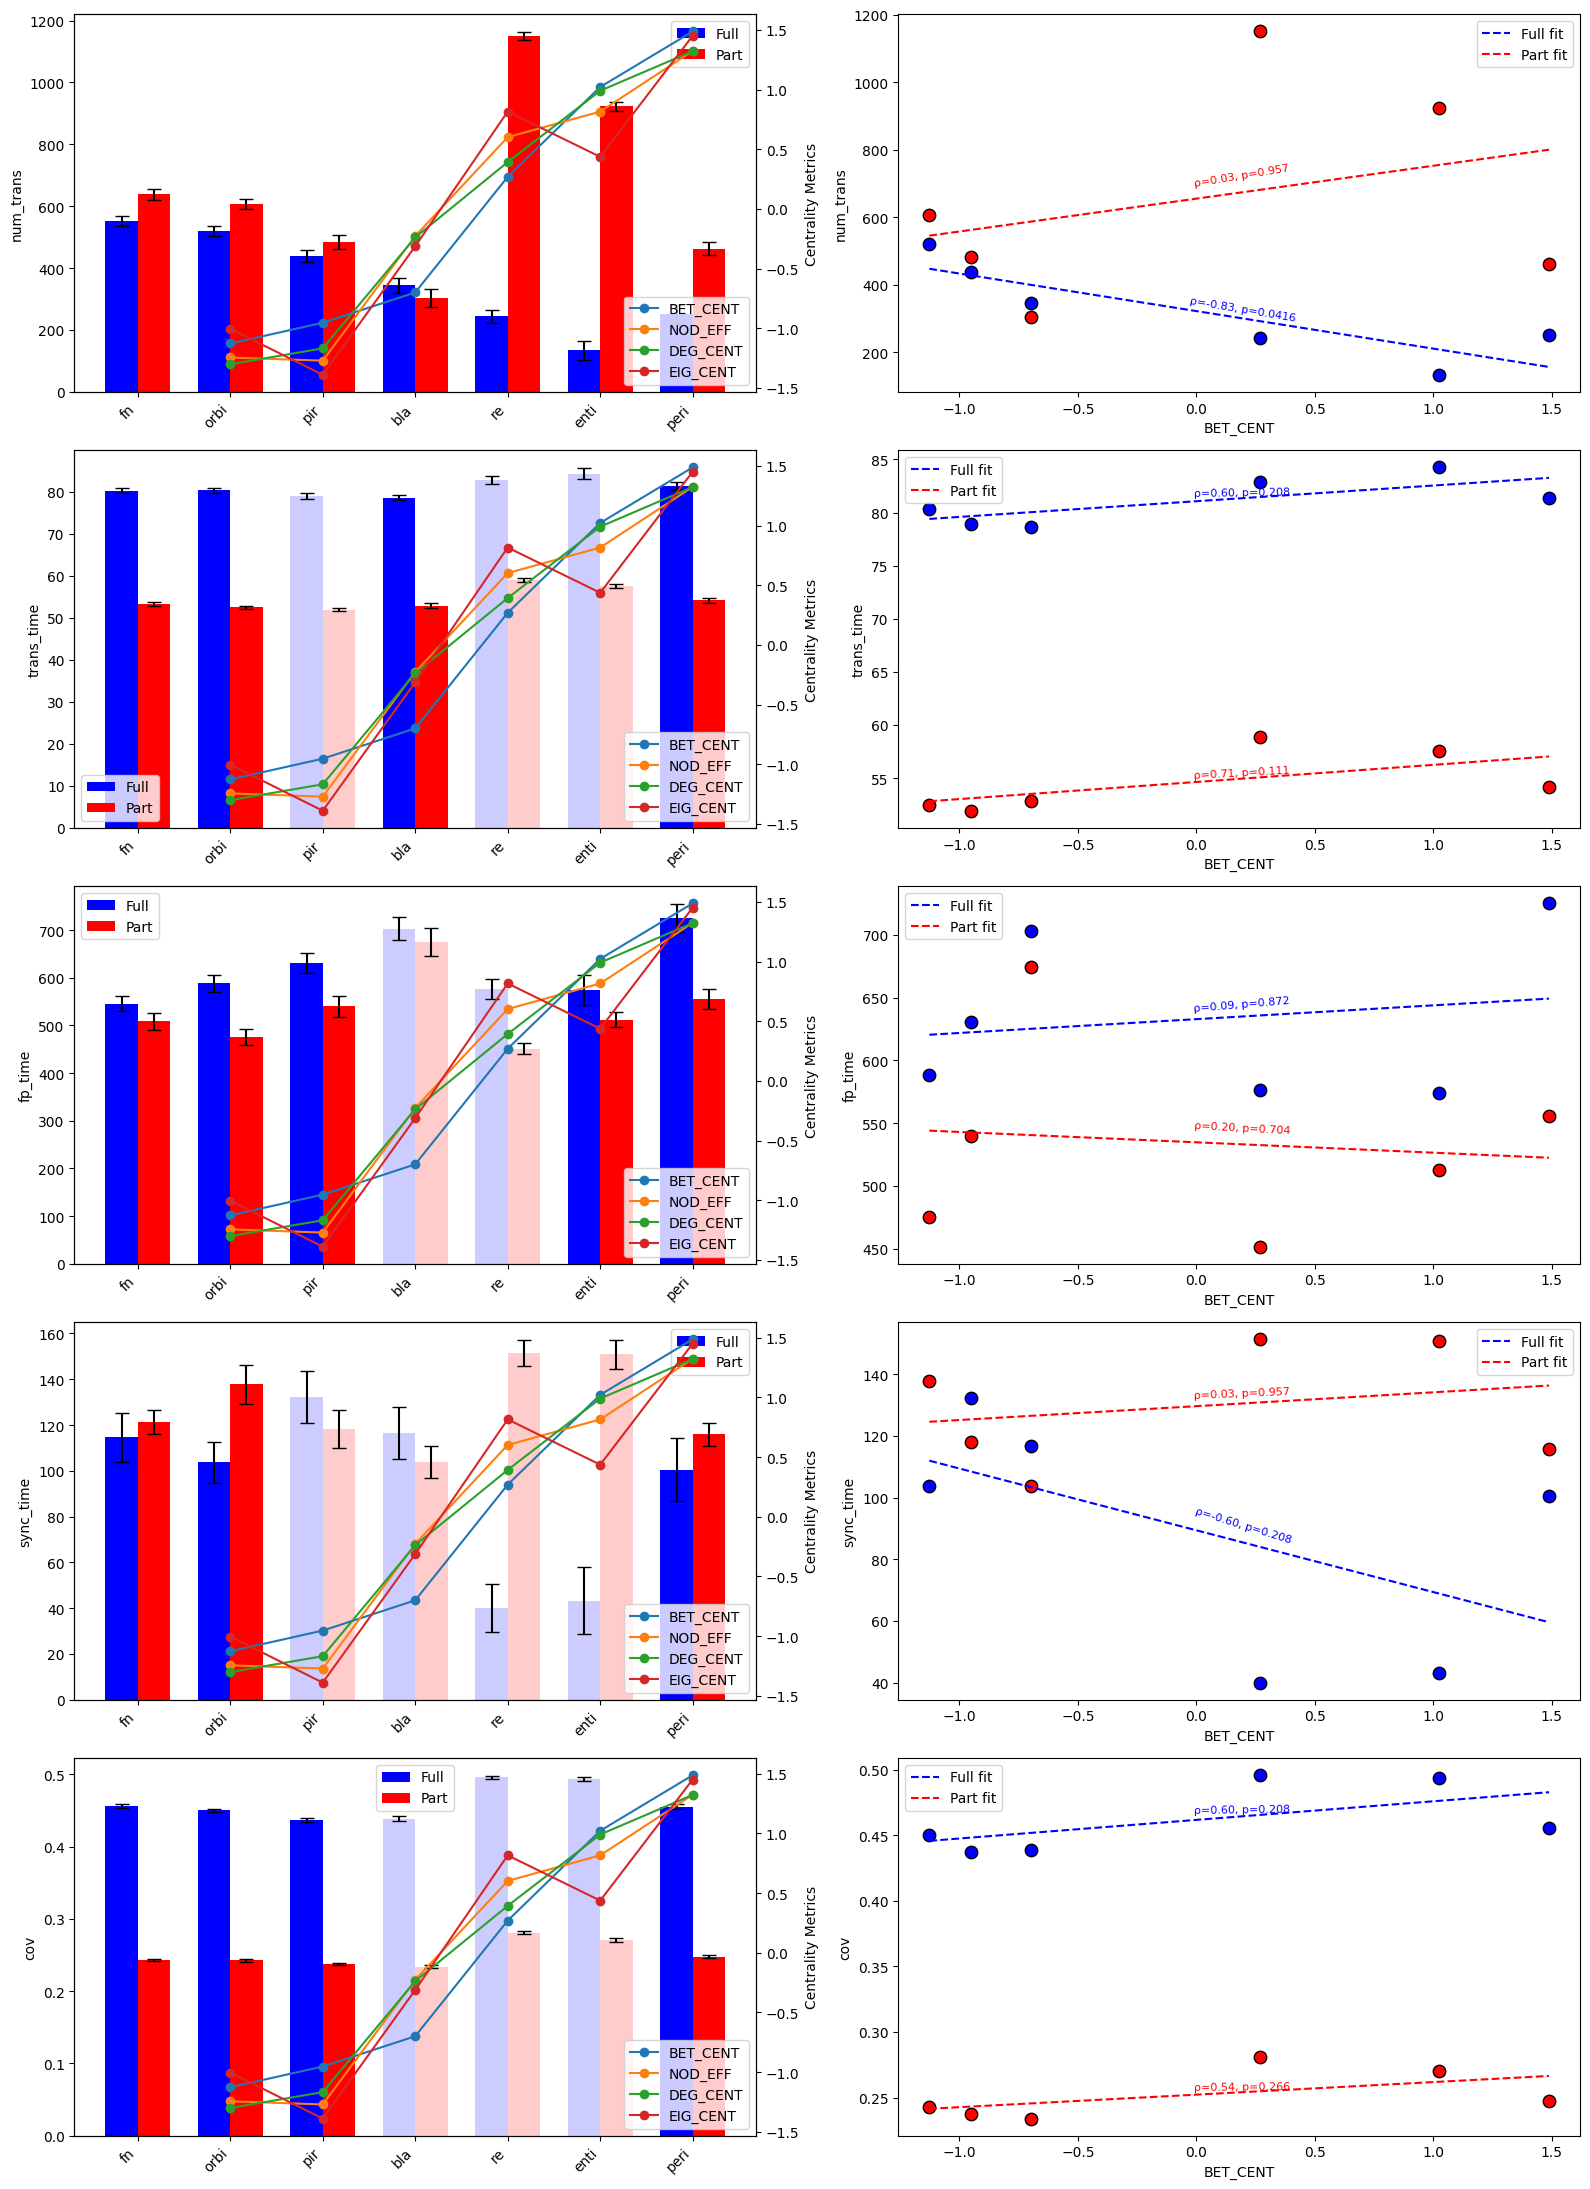

In [237]:
f, ((ax1, ax01), (ax2, ax02), (ax3, ax03), (ax4, ax04), (ax5, ax05)) = plt.subplots(
    5, 2, figsize=(16, 22), sharex=False
)
parameters = ["trans_time", "fp_time", "sync_time", "cov"]
fig_3_bar_num_trans(ax1, "num_trans")
fig_3_scatter(ax01, "num_trans", 80, -80)

fig_3_bar(ax2, "trans_time")
fig_3_scatter(ax02, "trans_time", -55, -55)

fig_3_bar(ax3, "fp_time")
fig_3_scatter(ax03, "fp_time", -80, 80)

fig_3_bar(ax4, "sync_time")
fig_3_scatter(ax04, "sync_time", 70, -75)

fig_3_bar(ax5, "cov")
fig_3_scatter(ax05, "cov", 0, 0)

# f.suptitle('Figure 3')
f.tight_layout()
# f.savefig('fig_3.png')
f.savefig("fig_3_1000.png")

## Final plot -(parameters on MTS vs Degree plot)

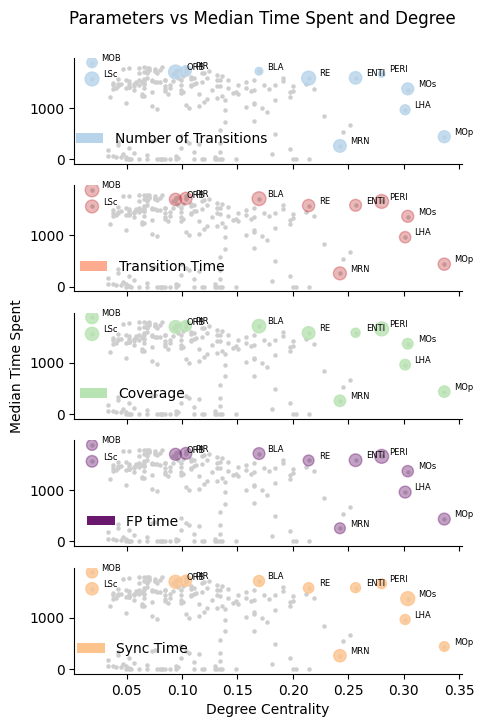

In [65]:
f, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(5, 8), sharex=True)

f.suptitle("Parameters vs Median Time Spent and Degree", x=0.5, y=0.94)
ax1.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
max = df["TRANS_COUNT"].max()
ax1.scatter(
    d,
    mts_vals,
    s=df["TRANS_COUNT"].apply(lambda x: ((10 * x / max)) ** 2),
    color=cm.Blues(0.3),
    alpha=0.8,
)
ax1.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax1.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1


ax2.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
max = df["TRANS_TIME"].max()
ax2.scatter(
    d,
    mts_vals,
    s=df["TRANS_TIME"].apply(lambda x: ((10 * x / max)) ** 2),
    color=cm.Reds(0.8),
    alpha=0.3,
)
ax2.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax2.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1


ax3.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
max = df["COVERAGE"].max()
ax3.scatter(
    d,
    mts_vals,
    s=df["COVERAGE"].apply(lambda x: ((10 * x / max)) ** 2),
    color=cm.Greens(0.3),
    alpha=0.8,
)
ax3.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax3.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1
ax3.set_ylabel("Median Time Spent")


ax4.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
max = df["FP_TIME"].max()
ax4.scatter(
    d,
    mts_vals,
    s=df["FP_TIME"].apply(lambda x: ((10 * x / max)) ** 2),
    color=cm.inferno(0.3),
    alpha=0.4,
)
ax4.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax4.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1


ax5.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
max = df["SYNC_TIME"].max()
ax5.scatter(
    d,
    mts_vals,
    s=df["SYNC_TIME"].apply(lambda x: ((10 * x / max)) ** 2),
    color=cm.Oranges(0.3),
    alpha=0.8,
)
ax5.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax5.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1
ax5.set_xlabel("Degree Centrality")
# Create custom legend
custom_patches = [
    Patch(facecolor=cm.Blues(0.3), label="Number of Transitions"),
    Patch(facecolor=cm.Reds(0.3), label="Transition Time"),
    Patch(facecolor=cm.Greens(0.3), label="Coverage"),
    Patch(facecolor=cm.inferno(0.3), label="FP time"),
    Patch(facecolor=cm.Oranges(0.3), label="Sync Time"),
]
p1 = [Patch(facecolor=cm.Blues(0.3), label="Number of Transitions")]
ax1.legend(handles=p1, loc="lower center", bbox_to_anchor=(0.25, 0.05), frameon=False)

p2 = [Patch(facecolor=cm.Reds(0.3), label="Transition Time")]
ax2.legend(handles=p2, loc="lower center", bbox_to_anchor=(0.2, 0.05), frameon=False)

p3 = [Patch(facecolor=cm.Greens(0.3), label="Coverage")]
ax3.legend(handles=p3, loc="lower center", bbox_to_anchor=(0.15, 0.05), frameon=False)


p4 = [Patch(facecolor=cm.inferno(0.3), label="FP time")]
ax4.legend(handles=p4, loc="lower center", bbox_to_anchor=(0.15, 0.05), frameon=False)

p5 = [Patch(facecolor=cm.Oranges(0.3), label="Sync Time")]
ax5.legend(handles=p5, loc="lower center", bbox_to_anchor=(0.15, 0.05), frameon=False)

# f.legend(handles=custom_patches,
#          loc='upper center',
#          ncol=3, frameon=False,
#          bbox_to_anchor=(0.5, 1))
f.savefig("fig_3.png")
f.show()

## Figure 5: Time of Entry of nodes community wise

- uses node community data (which considers old algo to find out time points where transition occurs, though it always finds out when exactly the best concrete transition occurs )
- defining function which calculates median time of entry of a particular node in main cluster in 200 iterations


In [66]:
def avg_toe(df):
    i = 0
    f = 5000
    # df=df_r_fn
    toe = []
    while f < df.shape[0]:
        mc = analyse.compute_main_cluster(df.iloc[i:f, :])
        t = analyse.compute_toe(df.iloc[i:f, :], mc)
        toe.append(t)
        i = f
        f += 5000
    # can use mean or median accordingly

    col_mean = np.median(np.array(toe), axis=0)
    return col_mean

### Reading node community data

In [67]:
FN_folder = Path("../../data/raw/FN/")
ENTI_folder = Path("../../data/raw/ENTI/")
ORBI_folder = Path("../../data/raw/ORBI/")
PERI_folder = Path("../../data/raw/PERI/")
PIR_folder = Path("../../data/raw/PIR/")
RE_folder = Path("../../data/raw/RE/")
BLA_folder = Path("../../data/raw/BLA")
files = []
folders = [
    FN_folder,
    ENTI_folder,
    ORBI_folder,
    PERI_folder,
    PIR_folder,
    RE_folder,
    BLA_folder,
]
label = ["FN", "ENTI", "ORBI", "PERI", "PIR", "RE", "BLA"]
for folder in folders:
    file = glob.glob(str(folder / "nc_200.bz2"))
    files.append(file)

print(files)
toe = []
for f in files:
    df_nc = pd.read_pickle(f[0], compression="bz2")
    df_r = df_nc.reset_index(drop=True)
    mean_toe = avg_toe(df_r)
    toe.append(mean_toe)

# Sorting by communities
desired_order = list(reader.get_communities()["des_order"])
df_toe = pd.DataFrame(toe, index=label).T

# very powerful, whenever you concat any node data to community map, it automatically arranges in that order
toe_plot_data = pd.concat(
    [reader.get_communities()["comm_map"].to_frame(), df_toe], axis=1
)
toe_plot_data.columns = ["community", "FN", "ENTI", "ORBI", "PERI", "PIR", "RE", "BLA"]

[['../../data/raw/FN/nc_200.bz2'], ['../../data/raw/ENTI/nc_200.bz2'], ['../../data/raw/ORBI/nc_200.bz2'], ['../../data/raw/PERI/nc_200.bz2'], ['../../data/raw/PIR/nc_200.bz2'], ['../../data/raw/RE/nc_200.bz2'], ['../../data/raw/BLA/nc_200.bz2']]


### Calculating mean, median and mad

In [68]:
toe_stats = toe_plot_data.groupby("community")[
    ["FN", "ENTI", "ORBI", "PERI", "PIR", "RE", "BLA"]
].agg(["mean", "median", "mad"])
print(toe_stats)

                    FN                             ENTI                      \
                  mean  median         mad         mean  median         mad   
community                                                                     
HIND       4286.802326  4999.0  755.848567  4300.511628  4934.5  739.672796   
HIPP       3031.880000  3400.0  598.872000  2982.960000  3392.0  678.664000   
HTh        3224.181818  3329.5  209.520661  3190.681818  3311.5  239.853306   
MID        3434.757143  3443.5  145.142449  3398.571429  3406.5  133.906122   
MO         3106.000000  3278.5  372.964286  3135.535714  3275.5  304.096939   
OLF        2493.583333  2846.0  641.986111  2709.138889  2998.5  680.766975   
ORB        3197.352941  3289.5  196.816609  3187.500000  3246.0  180.441176   
VIS        3175.800000  3298.5  259.848000  3159.380000  3276.0  237.597600   

                  ORBI                              PERI  ...              \
                  mean   median         mad         m

/tmp/ipykernel_3474659/2640217317.py:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  toe_stats=toe_plot_data.groupby('community')[['FN','ENTI','ORBI','PERI','PIR','RE','BLA']].agg(['mean','median','mad'])
/tmp/ipykernel_3474659/2640217317.py:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  toe_stats=toe_plot_data.groupby('community')[['FN','ENTI','ORBI','PERI','PIR','RE','BLA']].agg(['mean','median','mad'])
/tmp/ipykernel_3474659/2640217317.py:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  toe_stats=toe_plot_data.groupby('community')[['FN','ENTI','ORBI','PERI','PIR','RE','BLA']].agg(['mean','median','mad'])
/tmp/ipykernel_3474659/2640217317.py:

### Sort each NOI wrt mean

In [77]:
to_sort = toe_stats
toe_stats = to_sort.sort_values(("FN", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("ENTI", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("ORBI", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("PERI", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("PIR", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("RE", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("BLA", "mean"), ascending=True)
print(toe_stats)

                    FN                             ENTI                      \
                  mean  median         mad         mean  median         mad   
community                                                                     
OLF        2493.583333  2846.0  641.986111  2709.138889  2998.5  680.766975   
HIPP       3031.880000  3400.0  598.872000  2982.960000  3392.0  678.664000   
VIS        3175.800000  3298.5  259.848000  3159.380000  3276.0  237.597600   
MO         3106.000000  3278.5  372.964286  3135.535714  3275.5  304.096939   
HTh        3224.181818  3329.5  209.520661  3190.681818  3311.5  239.853306   
ORB        3197.352941  3289.5  196.816609  3187.500000  3246.0  180.441176   
MID        3434.757143  3443.5  145.142449  3398.571429  3406.5  133.906122   
HIND       4286.802326  4999.0  755.848567  4300.511628  4934.5  739.672796   

                  ORBI                              PERI  ...              \
                  mean   median         mad         m

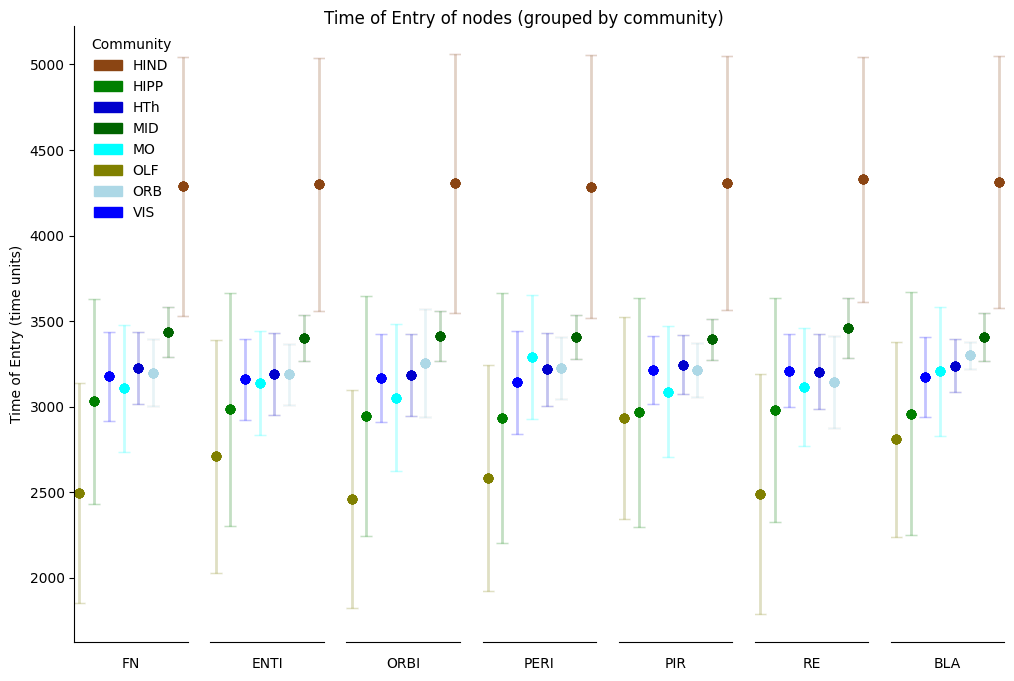

In [78]:
l = reader.get_communities()["comm_val"]
l = l.to_dict()
comm = ["MO", "VIS", "ORB", "HTh", "OLF", "HIPP", "MID", "HIND"]

node_c_avi = [
    "#00FFFF",
    "#0000FF",
    "#ADD8E6",
    "#0000CD",
    "#808000",
    "#008000",
    "#006400",
    "#8B4513",
]
colors = {
    "HIND": "#8B4513",
    "HIPP": "#008000",
    "HTh": "#0000CD",
    "MID": "#006400",
    "MO": "#00FFFF",
    "OLF": "#808000",
    "ORB": "#ADD8E6",
    "VIS": "#0000FF",
}
fig, ax = plt.subplots(1, 7, sharex=True, sharey=True, figsize=(12, 8))


node_c_nim = [
    "#FF0000",
    "#00FF00",
    "#0000FF",
    "#FFFF00",
    "#00FFFF",
    "#FF00FF",
    "#FFA500",
    "#800080",
]
col = dict(zip(comm, node_c_nim))
grouped = toe_plot_data.groupby("community")
for community, group in grouped:
    k = 0
    for idx, row in toe_stats["FN"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[0].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
            label=idx,
        )
        k += 1

        ax[0].set_ylabel("Time of Entry (time units)")
        # ax[0].spines[["left", "right", "top", "bottom"]].set_visible(False)
        # ax[0].set_xticks([50])
        ax[0].set_xticklabels([])
        ax[0].set_xlabel("FN")
    # ax[0].tick_params(axis="both", which="both", length=0)

    k = 0
    for idx, row in toe_stats["ENTI"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[1].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1

        # ax[0].spines[["left", "right", "top", "bottom"]].set_visible(False)
        # ax[0].set_xticks([50])

        # ax[1].set_xticks([50])
        ax[1].set_xticklabels([])
        ax[1].set_xlabel("ENTI")

    k = 0
    for idx, row in toe_stats["ORBI"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[2].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[2].set_xticklabels([])
        ax[2].set_xlabel("ORBI")

    k = 0
    for idx, row in toe_stats["PERI"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[3].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[3].set_xticklabels([])
        ax[3].set_xlabel("PERI")

    k = 0
    for idx, row in toe_stats["PIR"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[4].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[4].set_xticklabels([])
        ax[4].set_xlabel("PIR")

    k = 0
    for idx, row in toe_stats["RE"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[5].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[5].set_xticklabels([])
        ax[5].set_xlabel("RE")

    k = 0
    for idx, row in toe_stats["BLA"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[6].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[6].set_xticklabels([])
        ax[6].set_xlabel("BLA")

import matplotlib.patches as mpatches

# Assuming your 'colors' dictionary already exists
legend_elements = [
    mpatches.Patch(color=color, label=label) for label, color in colors.items()
]

ax[0].legend(
    handles=legend_elements,
    title="Community",
    loc="upper center",  # tweak as needed
    frameon=False,
)

# Remove outlines: Remove top/right spines from each subplot and hide most of the x-axis spines
for i, a in enumerate(ax):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

    # Hide the bottom spine for all subplots except the first one:
    if i != 0:
        a.spines["bottom"].set_visible(False)
        a.tick_params(bottom=False)  # Remove tick marks on the x-axis
        a.spines["left"].set_visible(False)
        a.tick_params(left=False)
    else:
        a.spines["bottom"].set_visible(True)
        a.tick_params(bottom=True)

    # Ensure the left spine (y-axis) is visible:
    # a.spines['left'].set_visible(True)
    a.spines["bottom"].set_visible(True)
    a.tick_params(bottom=False)


# plt.legend()
plt.suptitle("Time of Entry of nodes (grouped by community)", x=0.5, y=0.9)
# plt.savefig('fig_3.png')
plt.show()

## Figure 4: Parameters for NOI (violin plots)
- Computed data and stored in results folder

In [ ]:
data_folder = Path("../../data/results/processed/")
files = glob.glob(str(data_folder / "itr*.bz2"))

tranPer_params = {}  # to store number of transitions
trans_params = {}  # to store transition times
sync_params = {}  # to store time spent in sync states
fpt_params = {}
cvr_params = {}
t_time = []
for f in files:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]  # e.g., "bla"
    df_d = pd.read_pickle(f, compression="bz2")
    df_d.columns = range(0, df_d.shape[1])

    # Compute parameters
    params = algo_pf.compute_param_df(df_d)
    reader.data_dump_pkl(f"results/partial_full_data_1000_itr/{name_suffix}", params)
    # # Store lists in the dictionary
    # tranPer_params[f"{name_suffix}"] = params["tran_per"]
    # trans_params[f"{name_suffix}"] = params['trans']
    # # removing those which have sync state time zero
    # sync=[i for i in params['sync'] if i!=0]
    # sync_params[f"{name_suffix}"] = sync
    # fpt_params[f"{name_suffix}"] = params["fpt"]
    # cvr=[j for j in params['cov'] if j!=0 and not np.isnan(j)]
    # cvr_params[f"{name_suffix}"] = cvr
    print(f"{f} DONE")

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

0


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


35125
1
2


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

...

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


6841
307


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


308


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [23]:
params.keys()

dict_keys(['tran_per', 'sync', 'trans', 'fpt', 'cov'])

In [24]:
reader.data_dump_pkl("new_algo_param.pkl", params)

In [25]:
param_check = reader.data_read_pkl("new_algo_param.pkl")

## Stored parameter data

In [31]:
reader.data_dump_pkl("n_sync_state.pkl", sync_params)
reader.data_dump_pkl("n_trans_time.pkl", trans_params)
reader.data_dump_pkl("n_fpt.pkl", fpt_params)
reader.data_dump_pkl("n_transPer.pkl", tranPer_params)
reader.data_dump_pkl("n_cvr.pkl", cvr_params)

## Read stored data

In [6]:
sync_params = reader.data_read_pkl("n_sync_state.pkl")
trans_params = reader.data_read_pkl("n_trans_time.pkl")
tranPer_params = reader.data_read_pkl("n_transPer.pkl")
fpt_params = reader.data_read_pkl("n_fpt.pkl")
cvr_params = reader.data_read_pkl("n_cvr.pkl")

In [15]:
trans_params.keys()

dict_keys(['bla', 'enti', 'fn', 'orbi', 'peri', 'pir', 're'])

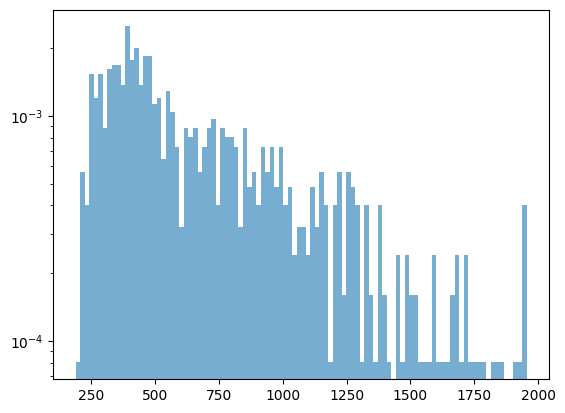

In [36]:
plt.figure()
# plt.hist(cvr_params['fn'],bins=100,alpha=0.6, density=True)
plt.hist(fpt_params["re"], bins=100, alpha=0.6, density=True)
plt.yscale("log")

In [33]:
print(
    np.std(trans_params["fn"]) / np.sqrt(len(trans_params["fn"])),
    np.mean(trans_params["fn"]),
)
np.std(cvr_params["re"]) / np.sqrt(len(cvr_params["re"])), np.mean(cvr_params["re"])

0.5467843743932821 63.5948275862069


(0.48735554247677393, 61.50679644808744)

In [28]:
scipy.stats.mannwhitneyu(trans_params["re"], trans_params["fn"])

MannwhitneyuResult(statistic=876494.5, pvalue=0.005346144521147316)

In [27]:
scipy.stats.ttest_ind(trans_params["re"], trans_params["fn"])

Ttest_indResult(statistic=-2.8587621750070635, pvalue=0.0042851326245333535)

In [7]:
node_order = np.array(["fn", "bla", "enti", "orbi", "peri", "pir", "re"])
non = np.r_[np.argsort([tranPer_params[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]
non

array([1, 4, 5, 2, 3, 6, 0])

#### GEtting per 100 transitions

In [8]:
for key, value in tranPer_params.items():
    dum = np.array(value)
    value = list(np.diff(dum))
    tranPer_params[key] = value

print(tranPer_params)

{'bla': [80, 62, 71, 70, 62, 55, 79, 76, 81, 49], 'enti': [108, 93, 126, 134, 91, 106, 133, 103, 100, 129], 'fn': [132, 140, 132, 116, 111, 112, 175, 114, 118, 128], 'orbi': [120, 142, 108, 97, 131, 128, 97, 137, 115, 141], 'peri': [63, 83, 79, 76, 101, 75, 56, 85, 69, 95], 'pir': [91, 95, 90, 110, 110, 79, 100, 108, 107, 82], 're': [154, 139, 160, 160, 138, 151, 144, 149, 138, 137]}


## Man whitne U test to find if there is sinificant shift in median position

In [9]:
# simulate two distributions

cvr_node = []
group1 = np.asarray(cvr_params["fn"])
for k in node_order[non]:
    group2 = np.asarray(cvr_params[k])

    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative="two-sided")
    if p < 0.05:
        cvr_node.append(k)
    print(f" Sync state: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f"Significant node: {cvr_node}")

 Sync state: bla Mann–Whitney U = 161296.0, p = 0.031
 Sync state: peri Mann–Whitney U = 176650.0, p = 0.000
 Sync state: pir Mann–Whitney U = 200787.0, p = 0.043
 Sync state: enti Mann–Whitney U = 225412.0, p = 0.000
 Sync state: orbi Mann–Whitney U = 238687.0, p = 0.161
 Sync state: re Mann–Whitney U = 278484.0, p = 0.000
 Sync state: fn Mann–Whitney U = 242904.5, p = 1.000
Significant node: ['bla', 'peri', 'pir', 'enti', 're']


In [10]:
# simulate two distributions

sync_node = []
group1 = np.asarray(sync_params["fn"])
for k in node_order[non]:
    group2 = np.asarray(sync_params[k])

    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative="two-sided")
    if p < 0.05:
        sync_node.append(k)
    print(f" Sync state: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f"Significant node: {sync_node}")

 Sync state: bla Mann–Whitney U = 38006.0, p = 0.992
 Sync state: peri Mann–Whitney U = 43587.0, p = 0.206
 Sync state: pir Mann–Whitney U = 47010.5, p = 0.829
 Sync state: enti Mann–Whitney U = 56574.5, p = 0.728
 Sync state: orbi Mann–Whitney U = 55035.5, p = 0.927
 Sync state: re Mann–Whitney U = 66698.0, p = 0.711
 Sync state: fn Mann–Whitney U = 57122.0, p = 1.000
Significant node: []


In [11]:
trans_node = []
group1 = np.asarray(trans_params["fn"])
for k in node_order[non]:
    group2 = np.asarray(trans_params[k])

    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative="two-sided")
    if p < 0.05:
        trans_node.append(k)
    print(f" Duration: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f"Significant node: {trans_node}")

 Duration: bla Mann–Whitney U = 408813.5, p = 0.027
 Duration: peri Mann–Whitney U = 528219.0, p = 0.019
 Duration: pir Mann–Whitney U = 634659.5, p = 0.434
 Duration: enti Mann–Whitney U = 797628.0, p = 0.000
 Duration: orbi Mann–Whitney U = 785391.5, p = 0.475
 Duration: re Mann–Whitney U = 991569.5, p = 0.005
 Duration: fn Mann–Whitney U = 814088.0, p = 1.000
Significant node: ['bla', 'peri', 'enti', 're']


In [12]:
tranPer_node = []
group1 = np.asarray(tranPer_params["fn"])
for k in node_order[non]:
    group2 = np.asarray(tranPer_params[k])

    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative="two-sided", method="exact")
    if p < 0.05:

        tranPer_node.append(k)
    print(f" #transition: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")
print(f"Significant node: {tranPer_node}")

 #transition: bla Mann–Whitney U = 100.0, p = 0.000
 #transition: peri Mann–Whitney U = 100.0, p = 0.000
 #transition: pir Mann–Whitney U = 100.0, p = 0.000
 #transition: enti Mann–Whitney U = 73.0, p = 0.089
 #transition: orbi Mann–Whitney U = 54.5, p = 0.796
 #transition: re Mann–Whitney U = 14.0, p = 0.005
 #transition: fn Mann–Whitney U = 50.0, p = 1.000
Significant node: ['bla', 'peri', 'pir', 're']


In [13]:
fpt_node = []
group1 = np.asarray(fpt_params["fn"])
for k in node_order[non]:
    group2 = np.asarray(fpt_params[k])

    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative="two-sided")
    if p < 0.05:
        fpt_node.append(k)
    print(f" FPT: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f"Significant node: {fpt_node}")

 FPT: bla Mann–Whitney U = 120613.5, p = 0.000
 FPT: peri Mann–Whitney U = 124427.5, p = 0.000
 FPT: pir Mann–Whitney U = 168573.5, p = 0.000
 FPT: enti Mann–Whitney U = 163811.0, p = 0.000
 FPT: orbi Mann–Whitney U = 229082.0, p = 0.581
 FPT: re Mann–Whitney U = 252453.0, p = 0.453
 FPT: fn Mann–Whitney U = 245000.0, p = 1.000
Significant node: ['bla', 'peri', 'pir', 'enti']


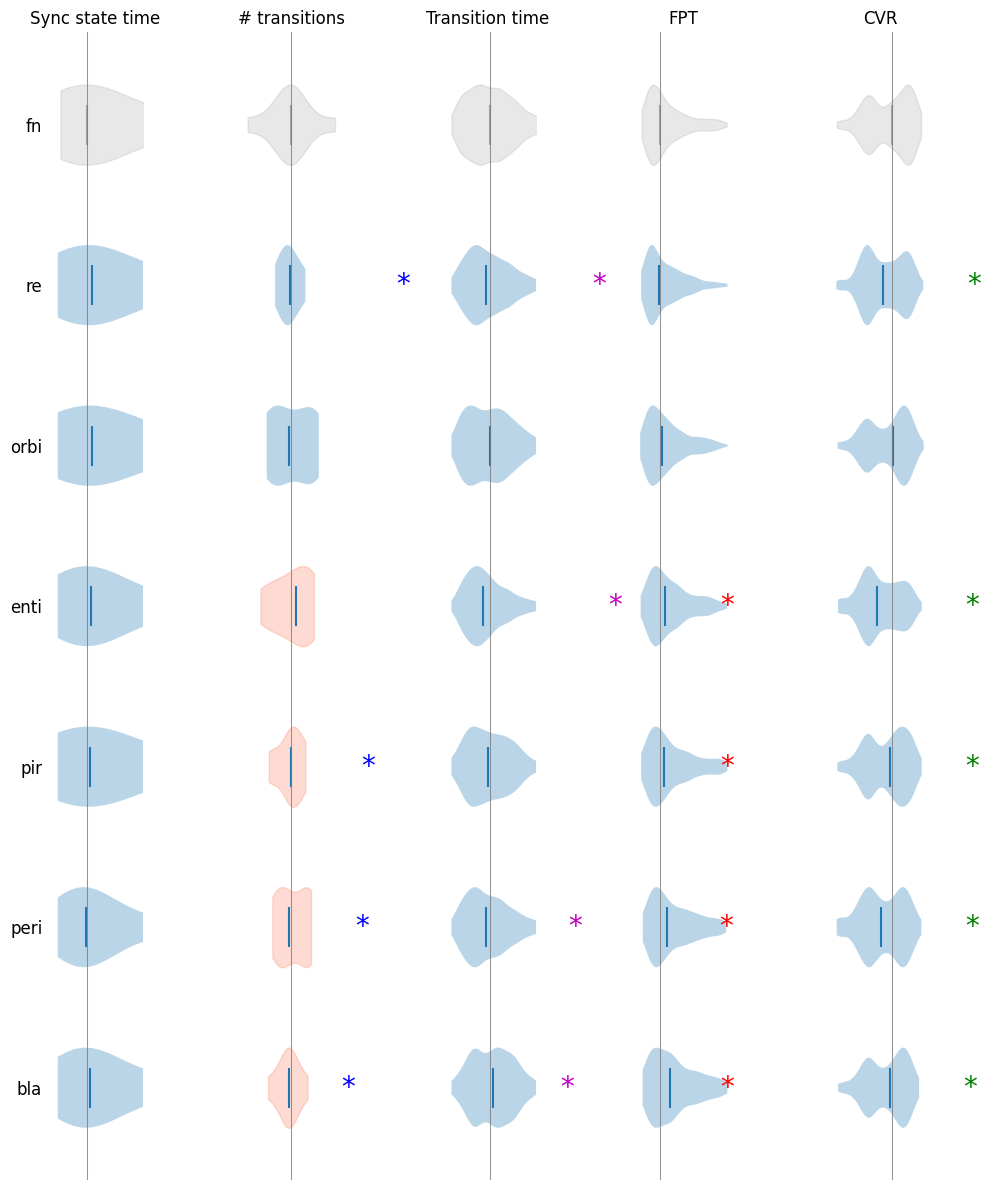

In [14]:
f, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(10, 12), sharey=True)

# ccoverage
_artists = ax5.violinplot(
    [cvr_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax4.set_yticks(np.arange(1, len(fpt_node) + 1))
# ax4.set_yticklabels(['*']*len(fpt_node), fontsize=30)

_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax5.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax5.set_xticks([])
# ax3.set_xlim(20, 100)
ax5.tick_params(axis="both", which="both", length=0)
ax5.set_title("CVR")
ax5.axvline(np.median(cvr_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)


offset = 0.3  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in cvr_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(cvr_params[node]) + offset
        y = idx
        ax5.text(x, y, "*", ha="center", va="center", color="green", fontsize=20)


# First passage time
_artists = ax4.violinplot(
    [fpt_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax4.set_yticks(np.arange(1, len(fpt_node) + 1))
# ax4.set_yticklabels(['*']*len(fpt_node), fontsize=30)

_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax4.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax4.set_xticks([])
# ax3.set_xlim(20, 100)
ax4.tick_params(axis="both", which="both", length=0)
ax4.set_title("FPT")
ax4.axvline(np.median(fpt_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)


offset = 0.3  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in fpt_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(fpt_params[node]) + offset
        y = idx
        ax4.text(x, y, "*", ha="center", va="center", color="red", fontsize=20)


# # number of transitions
_artists = ax3.violinplot(
    [trans_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order) + 1))
# ax3.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax3.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax3.set_xticks([])
ax3.set_xlim(20, 100)
ax3.tick_params(axis="both", which="both", length=0)
ax3.set_title("Transition time")
ax3.axvline(np.median(trans_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.05  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in trans_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(trans_params[node]) + offset
        y = idx
        ax3.text(x, y, "*", ha="center", va="center", color="m", fontsize=20)


# sync state
_artists = ax1.violinplot(
    [sync_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 200)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("Sync state time")
ax1.axvline(np.median(sync_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.01  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in sync_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(sync_params[node]) + offset
        y = idx
        ax1.text(x, y, "*", ha="center", va="center", color="red", fontsize=20)


# number of transitions
_artists = ax2.violinplot(
    [np.diff(np.array(tranPer_params[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(tranPer_params["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.01  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in tranPer_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(tranPer_params[node]) + offset
        y = idx
        ax2.text(x, y, "*", ha="center", va="center", color="blue", fontsize=20)

f.subplots_adjust(wspace=0.8)
f.tight_layout()
f.savefig("cntrl_param_violin.png")

# Reading data for control nodes and plotting violin plots with MU test

In [52]:
# read data of control nodes
data_folder = Path("../../data/raw/check_control/")
# control_nc=glob.glob(str(data_folder / "nc_200*.bz2"))
control_itr = glob.glob(str(data_folder / "itr_200*.bz2"))

tranPer_params = {}  # to store number of transitions
trans_params = {}  # to store transition times
sync_params = {}  # to store time spent in sync states
fpt_params = {}
cvr_params = {}
t_time = []
for f in control_itr:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]  # e.g., "bla"
    df_d = pd.read_pickle(f, compression="bz2")
    df_d.columns = range(0, df_d.shape[1])

    # Compute parameters
    params = algo.compute_param_df(df_d)

    # Store lists in the dictionary
    tranPer_params[f"{name_suffix}"] = params["tran_per"]
    trans_params[f"{name_suffix}"] = params["trans"]
    # removing those which have sync state time zero
    sync = [i for i in params["sync"] if i != 0]
    sync_params[f"{name_suffix}"] = sync
    fpt_params[f"{name_suffix}"] = params["fpt"]
    cvr = [j for j in params["cov"] if j != 0 and not np.isnan(j)]
    cvr_params[f"{name_suffix}"] = cvr
    print(f"{f} DONE")

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [7500, 11500, 15300, 21000, 26500, 30800]
8851
12836
16288
27676
31787
start [13200]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


13825
start [7800]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

16313
start [6400, 11700, 14100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


12086
15282


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [10000, 15500, 35600]
10949
16456
36669
../../data/raw/check_control/itr_200_fn.bz2 DONE


In [53]:
reader.data_dump_pkl("results/control_200_itr/n_sync_state.pkl", sync_params)
reader.data_dump_pkl("results/control_200_itr/n_trans_time.pkl", trans_params)
reader.data_dump_pkl("results/control_200_itr/n_fpt.pkl", fpt_params)
reader.data_dump_pkl("results/control_200_itr/n_transPer.pkl", tranPer_params)
reader.data_dump_pkl("results/control_200_itr/n_cvr.pkl", cvr_params)

In [64]:
sync_params = reader.data_read_pkl("results/control_200_itr/n_sync_state.pkl")
trans_params = reader.data_read_pkl("results/control_200_itr/n_trans_time.pkl")
fpt_params = reader.data_read_pkl("results/control_200_itr/n_fpt.pkl")
tranPer_params = reader.data_read_pkl("results/control_200_itr/n_transPer.pkl")
cvr_params = reader.data_read_pkl("results/control_200_itr/n_cvr.pkl")

In [65]:
node_order = np.array(["fn", "1", "2", "3", "4"])

non = np.r_[np.argsort([tranPer_params[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]

non

array([1, 3, 4, 2, 0])

In [56]:
for key, value in tranPer_params.items():
    dum = np.array(value)
    value = list(np.diff(dum))
    tranPer_params[key] = value

print(tranPer_params)

{'1': [102, 97], '2': [126, 148], '3': [109, 127], '4': [135, 113], 'fn': [134, 164]}
